In [18]:
import pandas as pd
from pathlib import Path
import numpy as np

file_path = Path("spiff_data-2 (2).csv")

df = pd.read_csv(file_path)


In [19]:
price_df = (
    df.drop(columns=["Unnamed: 0", "day"], errors="ignore")
      .apply(pd.to_numeric, errors="coerce")
)

price_df = price_df.mask(price_df >= 1000, np.nan)  # 1000 이상 값을 NaN 처리

log_return_df = np.log(price_df / price_df.shift(1)).iloc[1:].copy()

if "day" in df.columns:
    log_return_df.index = df["day"].iloc[1:].values

log_return_df


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
2,0.005666,0.017307,-0.010802,0.001949,0.009233,0.000966,0.003273
3,-0.003396,-0.001205,0.001302,0.013761,-0.005760,-0.000644,0.013390
4,-0.001986,-0.005743,-0.009590,0.002439,-0.014548,0.000966,-0.004848
5,-0.005125,0.003329,0.001751,0.001099,0.004678,0.001072,0.004445
6,0.003420,0.011415,0.004363,-0.004095,0.000000,0.001392,-0.004040
...,...,...,...,...,...,...,...
5452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5455,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Before row drop: 5455
After row drop: 4888
Removed rows: 567


,start,end,n_days,total_return,annual_return,annual_vol,sharpe_ratio,sortino_ratio,max_drawdown
window,,,,,,,,,
3M,67,5256,4825,75.40%,2.98%,4.10%,0.015,1.048,-10.66%
6M,130,5256,4762,81.38%,3.20%,4.06%,0.068,1.140,-10.79%
1Y,307,5256,4636,109.66%,4.11%,4.04%,0.285,1.477,-8.98%


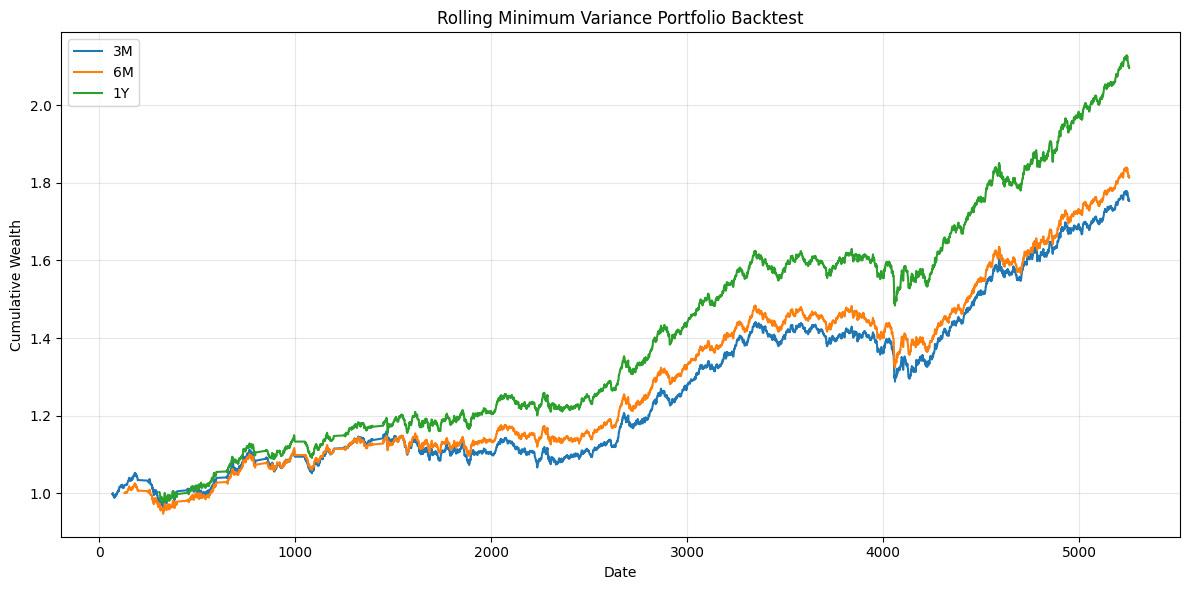

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
307,0.359768,9.587040e-19,1.875664e-02,0.021026,0.021399,0.487174,0.091876
308,0.368217,0.000000e+00,1.438558e-02,0.020423,0.023203,0.482061,0.091710
309,0.367275,1.041104e-17,1.489413e-02,0.020235,0.023354,0.482615,0.091628
310,0.367838,1.451733e-17,1.299645e-02,0.020680,0.026344,0.481652,0.090490
311,0.368642,0.000000e+00,1.340595e-02,0.020275,0.026058,0.481270,0.090349
312,0.373518,2.250545e-18,1.281813e-02,0.019326,0.027000,0.477497,0.089841
313,0.368924,1.675796e-17,1.266867e-02,0.022364,0.029164,0.477458,0.089421
314,0.380699,0.000000e+00,9.195191e-03,0.021367,0.029177,0.470499,0.089063
315,0.387087,6.391211e-21,3.569532e-03,0.021498,0.028803,0.469893,0.089150
316,0.384595,0.000000e+00,2.004708e-19,0.021323,0.029845,0.472923,0.091315


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
5237,0.772645,0.069817,0.061614,0.012834,0.019986,0.038180,0.024925
5238,0.770554,0.070030,0.061597,0.012947,0.019280,0.040423,0.025169
5239,0.772891,0.070753,0.061437,0.012851,0.019357,0.038677,0.024034
5240,0.772235,0.070945,0.061528,0.012741,0.019642,0.039242,0.023667
5241,0.780572,0.069324,0.063321,0.013536,0.022104,0.028817,0.022326
5242,0.774757,0.069920,0.063470,0.013407,0.023705,0.033144,0.021596
5243,0.774140,0.070133,0.064300,0.013325,0.023587,0.033493,0.021022
5244,0.774518,0.068621,0.065351,0.013123,0.022592,0.033830,0.021965
5245,0.769756,0.067207,0.068072,0.012730,0.022265,0.039170,0.020798
5246,0.757925,0.069207,0.067820,0.012336,0.022915,0.049411,0.020385


In [20]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Minimum Variance Portfolio Strategy

exclude_cols = ["day", "Unnamed: 0", "obs"]

raw_log_ret = (
    log_return_df
    .drop(columns=exclude_cols, errors="ignore")
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="all")
)

log_ret = raw_log_ret.dropna(axis=0, how="any").copy()

print(f"Before row drop: {len(raw_log_ret)}")
print(f"After row drop: {len(log_ret)}")
print(f"Removed rows: {len(raw_log_ret) - len(log_ret)}")


# Estimate covariance matrix
estimation_returns = log_ret.copy()
realized_returns = np.expm1(log_ret)

window_map = {
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

# Minimum Variance weight function
def long_only_gmvp_weights(cov_matrix, min_weight=0.0):
    cov = np.asarray(cov_matrix, dtype=float)
    n = cov.shape[0]

    init_w = np.repeat(1 / n, n)

    def portfolio_variance(w):
        return float(w @ cov @ w)


    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1}  #Constraint for Optimization: total of weight sum is 1
    ]

    bounds = [(min_weight, 1.0) for _ in range(n)]

    result = minimize(
        portfolio_variance,
        x0=init_w,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-18, "maxiter": 1000}
    )

    if not result.success:
        return init_w

    return result.x

# 3) Perfomance indicator  
def compute_metrics(port_ret, annualization=252, rf_annual=0.03):
    port_ret = port_ret.dropna()

    wealth = (1 + port_ret).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    mean_daily = port_ret.mean()
    vol_daily = port_ret.std(ddof=1)

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1

    excess_ret = port_ret - rf_daily
    mean_excess_daily = excess_ret.mean()

    downside = np.minimum(port_ret, 0)
    downside_dev = np.sqrt((downside ** 2).mean())

    sharpe = np.nan if np.isclose(vol_daily, 0) else (mean_excess_daily / vol_daily) * np.sqrt(annualization)
    sortino = np.nan if np.isclose(downside_dev, 0) else (mean_daily / downside_dev) * np.sqrt(annualization)

    metrics = {
        "start": port_ret.index[0],
        "end": port_ret.index[-1],
        "n_days": len(port_ret),
        "total_return": wealth.iloc[-1] - 1,
        "annual_return": wealth.iloc[-1] ** (annualization / len(port_ret)) - 1,
        "annual_vol": vol_daily * np.sqrt(annualization),
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": drawdown.min(),
    }

    return metrics, wealth, drawdown


def backtest_min_var(estimation_returns, realized_returns, window, min_obs_ratio=0.9, annualization=252):
    portfolio_returns = []
    weights_history = []

    min_obs = int(np.ceil(window * min_obs_ratio))

    for t in range(window - 1, len(estimation_returns) - 1):
        hist_window = estimation_returns.iloc[t - window + 1 : t + 1]
        next_day_realized = realized_returns.iloc[t + 1]

        eligible_cols = hist_window.columns[
            (hist_window.notna().sum() >= min_obs) & next_day_realized.notna()
        ]

        if len(eligible_cols) < 2:
            continue

        cov = hist_window[eligible_cols].cov(min_periods=min_obs)

        valid_mask = ~(cov.isna().any(axis=0) | cov.isna().any(axis=1))
        valid_cols = cov.columns[valid_mask]

        if len(valid_cols) < 2:
            continue

        cov = cov.loc[valid_cols, valid_cols]
        w = long_only_gmvp_weights(cov.values)

        realized_ret = float(np.dot(w, next_day_realized.loc[valid_cols].values))
        portfolio_returns.append((realized_returns.index[t + 1], realized_ret))

        weight_row = pd.Series(np.nan, index=realized_returns.columns, name=realized_returns.index[t + 1])
        weight_row.loc[valid_cols] = w
        weights_history.append(weight_row)

    port_ret = pd.Series(
        [x[1] for x in portfolio_returns],
        index=[x[0] for x in portfolio_returns],
        name=f"min_var_{window}"
    )

    weights_df = pd.DataFrame(weights_history)
    metrics, wealth, drawdown = compute_metrics(port_ret, annualization=annualization)

    return {
        "portfolio_returns": port_ret,
        "weights": weights_df,
        "wealth": wealth,
        "drawdown": drawdown,
        "metrics": metrics,
    }

results = {}
metrics_table = []

for label, window in window_map.items():
    res = backtest_min_var(
        estimation_returns=estimation_returns,
        realized_returns=realized_returns,
        window=window,
        min_obs_ratio=0.9,   
        annualization=252
    )
    results[label] = res

    row = {"window": label}
    row.update(res["metrics"])
    metrics_table.append(row)

metrics_df = pd.DataFrame(metrics_table).set_index("window")

display(
    metrics_df.style.format({
        "total_return": "{:.2%}",
        "annual_return": "{:.2%}",
        "annual_vol": "{:.2%}",
        "sharpe_ratio": "{:.3f}",
        "sortino_ratio": "{:.3f}",
        "max_drawdown": "{:.2%}",
    })
)

# --------------------------------------------------
# Perfomance plot 
# --------------------------------------------------
plt.figure(figsize=(12, 6))

for label, res in results.items():
    if not res["wealth"].empty:
        plt.plot(res["wealth"].index, res["wealth"], label=label)

plt.title("Rolling Minimum Variance Portfolio Backtest")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(results["1Y"]["weights"].head(20))
display(results["1Y"]["weights"].tail(20))

Min Variance Portfolio는 종목간의 Covariance matrix를 기준으로 Portfolio의 변동성을 가장 최소화하는 Portfolio를 구성하는 것을 목표로 한다.
이때 Portfolio 구성 시점의 진짜 Covariance는 알 수 없기에 이를 추정해야하는데, 위 전략에서는 과거 데이터를 기준으로 이를 추정한다. Window는 6개월, 1년, 2년 and 3년으로 4개의 window에 대해서 Covariance를 추정한다.
우리는 매일 Covariance를 구해 매일 portfolio를 이를 기준으로 재구성한다. 즉, 매일 Portfolio를 rebalancing한다.

The Minimum Variance Portfolio aims to construct a portfolio that minimizes overall volatility based on the covariance matrix of the assets. Since the true covariance at the time of portfolio construction is unobservable, it must be estimated.

In this strategy, we estimate the covariance using historical data. We employ four different look-back windows—6 months, 1 year, 2 years, and 3 years—to perform the estimation. We calculate the covariance matrix daily and reconstruct the portfolio accordingly. In other words, the portfolio undergoes daily rebalancing.

,window,risk_aversion,start,end,n_days,total_return,annual_return,annual_vol,sharpe_ratio,sortino_ratio,max_drawdown
0,1Y,0.50,307,5256,4636,12.55%,0.64%,13.81%,-0.098,0.159,-50.54%
1,1Y,1.00,307,5256,4636,18.66%,0.93%,13.48%,-0.083,0.187,-44.43%
2,3M,0.50,67,5256,4825,-4.65%,-0.25%,16.45%,-0.112,0.093,-50.12%
3,3M,1.00,67,5256,4825,-10.71%,-0.59%,16.32%,-0.136,0.063,-53.06%
4,6M,0.50,130,5256,4762,-11.23%,-0.63%,15.70%,-0.150,0.052,-57.11%
5,6M,1.00,130,5256,4762,-11.18%,-0.63%,15.39%,-0.156,0.049,-57.37%


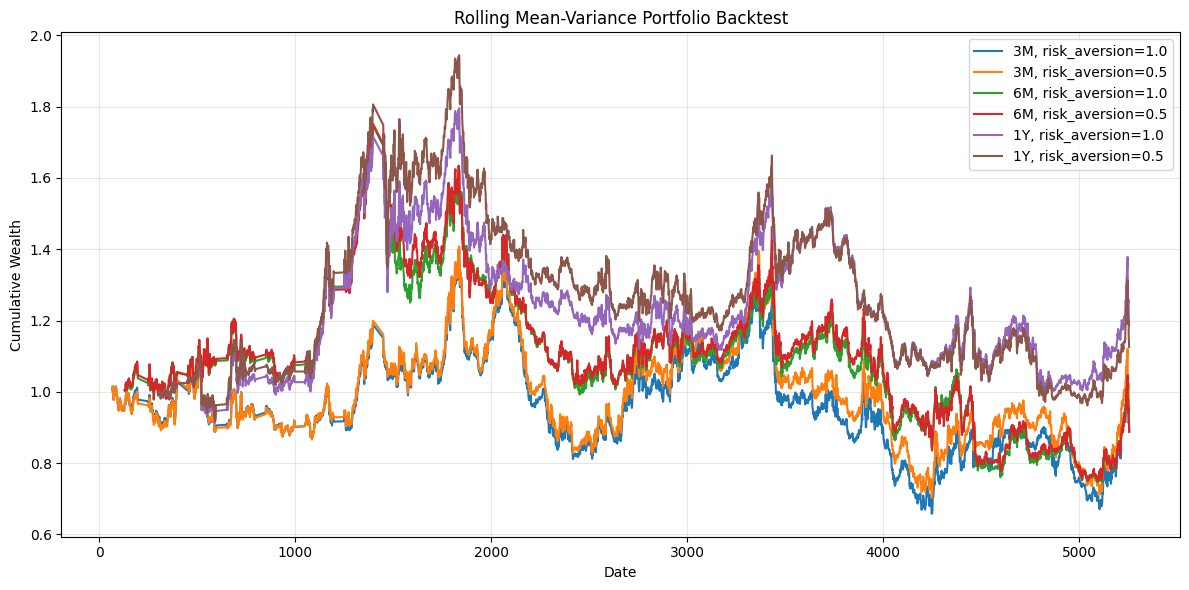

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
307,0.146801,0.224879,0.157630,0.000000e+00,0.187028,0.152625,0.131036
308,0.145163,0.224605,0.164203,1.387779e-17,0.180683,0.154763,0.130583
309,0.150780,0.225408,0.160821,1.387779e-17,0.180653,0.156511,0.125828
310,0.147212,0.224821,0.157245,0.000000e+00,0.196314,0.152406,0.122003
311,0.151292,0.218704,0.160675,0.000000e+00,0.192646,0.154037,0.122645
312,0.151313,0.216428,0.158205,0.000000e+00,0.196625,0.152082,0.125347
313,0.146994,0.220887,0.156914,2.775558e-17,0.203140,0.149049,0.123017
314,0.153772,0.209800,0.157436,0.000000e+00,0.195677,0.151435,0.131880
315,0.153400,0.215055,0.162382,0.000000e+00,0.193275,0.146659,0.129230
316,0.153764,0.213309,0.172471,5.551115e-17,0.189314,0.146083,0.125059


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
5237,7.421449e-17,0.000000e+00,0.000000e+00,2.390637e-01,0.760936,1.704408e-16,0.000000e+00
5238,3.914893e-18,0.000000e+00,0.000000e+00,1.715981e-01,0.828402,1.299639e-16,0.000000e+00
5239,0.000000e+00,3.191891e-16,1.620650e-16,1.375074e-01,0.862493,0.000000e+00,0.000000e+00
5240,0.000000e+00,0.000000e+00,0.000000e+00,8.603910e-02,0.913961,3.771753e-18,2.118691e-16
5241,0.000000e+00,0.000000e+00,1.630640e-16,9.046102e-02,0.909539,0.000000e+00,5.210249e-17
5242,0.000000e+00,4.653196e-16,6.768991e-16,2.093811e-15,1.000000,0.000000e+00,0.000000e+00
5243,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,1.081965e-17
5244,0.000000e+00,1.793281e-16,1.873501e-16,1.844268e-01,0.815573,0.000000e+00,0.000000e+00
5245,2.591957e-17,2.765281e-16,5.063066e-16,0.000000e+00,1.000000,0.000000e+00,0.000000e+00
5246,7.289659e-17,2.327063e-16,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,7.735731e-17


In [21]:
# Mean-Variance Portfolio Strategy

simple_ret = np.expm1(log_ret)

# mean and covariance estimation with same window
estimation_returns = simple_ret.copy()
realized_returns = simple_ret.copy()

window_map = {
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

risk_aversion_grid = [1.0, 0.5]   # risk weight candidates
min_weight = 0.0       

# Mean-Variance weight Function
def long_only_mean_variance_weights(mean_vec, cov_matrix, risk_aversion=1.0, min_weight=0.0, ridge=1e-8):
    mu = np.asarray(mean_vec, dtype=float)
    cov = np.asarray(cov_matrix, dtype=float)

    n = cov.shape[0]
    init_w = np.repeat(1 / n, n)


    def objective(w):
        port_mean = w @ mu
        port_var = w @ cov @ w
        return float(0.5 * risk_aversion * port_var - port_mean)

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    ]

    bounds = [(min_weight, 1.0) for _ in range(n)]

    result = minimize(
        objective,
        x0=init_w,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        return init_w

    return result.x


# Performance indicator
def compute_metrics(port_ret, annualization=252, rf_annual=0.03):
    port_ret = port_ret.dropna()

    if port_ret.empty:
        metrics = {
            "start": pd.NaT,
            "end": pd.NaT,
            "n_days": 0,
            "total_return": np.nan,
            "annual_return": np.nan,
            "annual_vol": np.nan,
            "sharpe_ratio": np.nan,
            "sortino_ratio": np.nan,
            "max_drawdown": np.nan,
        }
        return metrics, pd.Series(dtype=float), pd.Series(dtype=float)

    wealth = (1 + port_ret).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    mean_daily = port_ret.mean()
    vol_daily = port_ret.std(ddof=1)

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    mean_excess_daily = excess_ret.mean()

    downside = np.minimum(port_ret, 0)
    downside_dev = np.sqrt((downside ** 2).mean())

    sharpe = np.nan if np.isclose(vol_daily, 0) else (mean_excess_daily / vol_daily) * np.sqrt(annualization)
    sortino = np.nan if np.isclose(downside_dev, 0) else (mean_daily / downside_dev) * np.sqrt(annualization)

    metrics = {
        "start": port_ret.index[0],
        "end": port_ret.index[-1],
        "n_days": len(port_ret),
        "total_return": wealth.iloc[-1] - 1,
        "annual_return": wealth.iloc[-1] ** (annualization / len(port_ret)) - 1,
        "annual_vol": vol_daily * np.sqrt(annualization),
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": drawdown.min(),
    }

    return metrics, wealth, drawdown

def backtest_mean_variance(
    estimation_returns,
    realized_returns,
    window,
    risk_aversion=10.0,
    min_weight=0.0,
    min_obs_ratio=0.9,
    annualization=252
):
    portfolio_returns = []
    weights_history = []

    min_obs = int(np.ceil(window * min_obs_ratio))

    for t in range(window - 1, len(estimation_returns) - 1):
        hist_window = estimation_returns.iloc[t - window + 1 : t + 1]
        next_day_realized = realized_returns.iloc[t + 1]

        eligible_cols = hist_window.columns[
            (hist_window.notna().sum() >= min_obs) & next_day_realized.notna()
        ]

        if len(eligible_cols) < 2:
            continue

        cov = hist_window[eligible_cols].cov(min_periods=min_obs)

        valid_mask = ~(cov.isna().any(axis=0) | cov.isna().any(axis=1))
        valid_cols = cov.columns[valid_mask]

        if len(valid_cols) < 2:
            continue

        est_block = hist_window[valid_cols]
        mu = est_block.mean().values
        cov = est_block.cov(min_periods=min_obs).loc[valid_cols, valid_cols].values

        w = long_only_mean_variance_weights(
            mean_vec=mu,
            cov_matrix=cov,
            risk_aversion=risk_aversion,
            min_weight=min_weight
        )

        realized_ret = float(np.dot(w, next_day_realized.loc[valid_cols].values))
        portfolio_returns.append((realized_returns.index[t + 1], realized_ret))

        weight_row = pd.Series(np.nan, index=realized_returns.columns, name=realized_returns.index[t + 1])
        weight_row.loc[valid_cols] = w
        weights_history.append(weight_row)

    port_ret = pd.Series(
        [x[1] for x in portfolio_returns],
        index=[x[0] for x in portfolio_returns],
        name=f"mean_variance_{window}_risk_aversion_{risk_aversion}"
    )

    weights_df = pd.DataFrame(weights_history)
    metrics, wealth, drawdown = compute_metrics(port_ret, annualization=annualization)

    return {
        "portfolio_returns": port_ret,
        "weights": weights_df,
        "wealth": wealth,
        "drawdown": drawdown,
        "metrics": metrics,
    }


mv_results = {}
mv_metrics_table = []

for label, window in window_map.items():
    for risk_aversion in risk_aversion_grid:
        res = backtest_mean_variance(
            estimation_returns=estimation_returns,
            realized_returns=realized_returns,
            window=window,
            risk_aversion=risk_aversion,
            min_weight=min_weight,
            min_obs_ratio=0.9,
            annualization=252
        )
        key = (label, risk_aversion)
        mv_results[key] = res

        row = {
            "window": label,
            "risk_aversion": risk_aversion,
        }
        row.update(res["metrics"])
        mv_metrics_table.append(row)

mv_metrics_df = pd.DataFrame(mv_metrics_table).sort_values(
    ["window", "risk_aversion"]
).reset_index(drop=True)

display(
    mv_metrics_df.style.format({
        "risk_aversion": "{:.2f}",
        "total_return": "{:.2%}",
        "annual_return": "{:.2%}",
        "annual_vol": "{:.2%}",
        "sharpe_ratio": "{:.3f}",
        "sortino_ratio": "{:.3f}",
        "max_drawdown": "{:.2%}",
    })
)

# Performance plot
plt.figure(figsize=(12, 6))

for (label, risk_aversion), res in mv_results.items():
    if not res["wealth"].empty:
        plt.plot(
            res["wealth"].index,
            res["wealth"],
            label=f"{label}, risk_aversion={risk_aversion}"
        )

plt.title("Rolling Mean-Variance Portfolio Backtest")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_mv_row = mv_metrics_df.sort_values("sharpe_ratio", ascending=False).iloc[0]
best_mv_key = (best_mv_row["window"], best_mv_row["risk_aversion"])

display(mv_results[best_mv_key]["weights"].head(20))
display(mv_results[best_mv_key]["weights"].tail(20))

Mean Variance Portfolio 전략은 Portfolio의 return은 최대화하면서 Portfolio의 Variance는 최소화하는 전략이다.
이때 사람마다 선호하는 Variance의 수준이 다르기에 이를 risk_aversion 변수로 조절하며 전략을 수행하면 된다.
위 경우 분석을 단순화하기 위해 risk_aversion를 1로 고정하고 전략을 수행한다.
Min Variance Portfolio 전략과 마찬가지로 우리는 진짜 return과 variance를 알 수 없다.
따라서 Mean과 Covariance를 과거 데이터 기반으로 구하고 window는 6개월, 1년, 2년 그리고 3년을 기준으로 분석한다.
이때 Mean과 Covariance의 window는 일치하게 한다. 마찬가지로 매일 mean과 covariance를 추정하고, 매일 portfolio를 rebalancing한다.

The Mean-Variance Portfolio strategy aims to maximize the portfolio's return while minimizing its variance. Since individuals have different preferences for risk, this trade-off is managed by adjusting the risk_aversion parameter.

In this case, we test risk_aversion values of 1.0 and 0.5. Similar to the Minimum Variance Portfolio strategy, the true expected return and variance are unobservable.

Consequently, we estimate the Mean and Covariance based on historical data, using look-back windows of 6 months, 1 year, 2 years, and 3 years. The windows for both the Mean and Covariance are kept consistent. Furthermore, the mean and covariance are re-estimated daily, and the portfolio is rebalanced on a daily basis.

Train/Test split: 2 to 3787 | 3788 to 5256
Buy & Hold train performance for all holding periods


,Holding Period,Holding Days,Train Days,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic
0,3M,63,3421,0.158,4.20%,-27.03%,11.1%,1178 days,0.555,0.58
1,6M,126,3421,0.164,4.25%,-26.13%,7.5%,1176 days,0.558,0.61
2,1Y,252,3421,0.177,4.32%,-25.94%,5.5%,1176 days,0.553,0.65


Best Buy & Hold holding period selected by train Sharpe: 1Y
Buy & Hold test performance for selected holding period


,Selected Holding Period,Holding Days,Test Days,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic
0,1Y,252,1467,0.149,4.50%,-30.82%,7.3%,629 days,0.582,0.36


,target_weight
gurkor,0.142857
guitars,0.142857
slingshots,0.142857
stocks,0.142857
sugar,0.142857
water,0.142857
tranquillity,0.142857


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
5252,0.130976,0.141296,0.147087,0.158529,0.171023,0.133898,0.117191
5253,0.129684,0.142202,0.147970,0.156780,0.173277,0.132753,0.117335
5254,0.130262,0.140970,0.147494,0.156704,0.173216,0.132931,0.118423
5255,0.130607,0.142325,0.148752,0.156576,0.166464,0.133555,0.121721
5256,0.130871,0.141709,0.147642,0.155724,0.167980,0.133982,0.122092


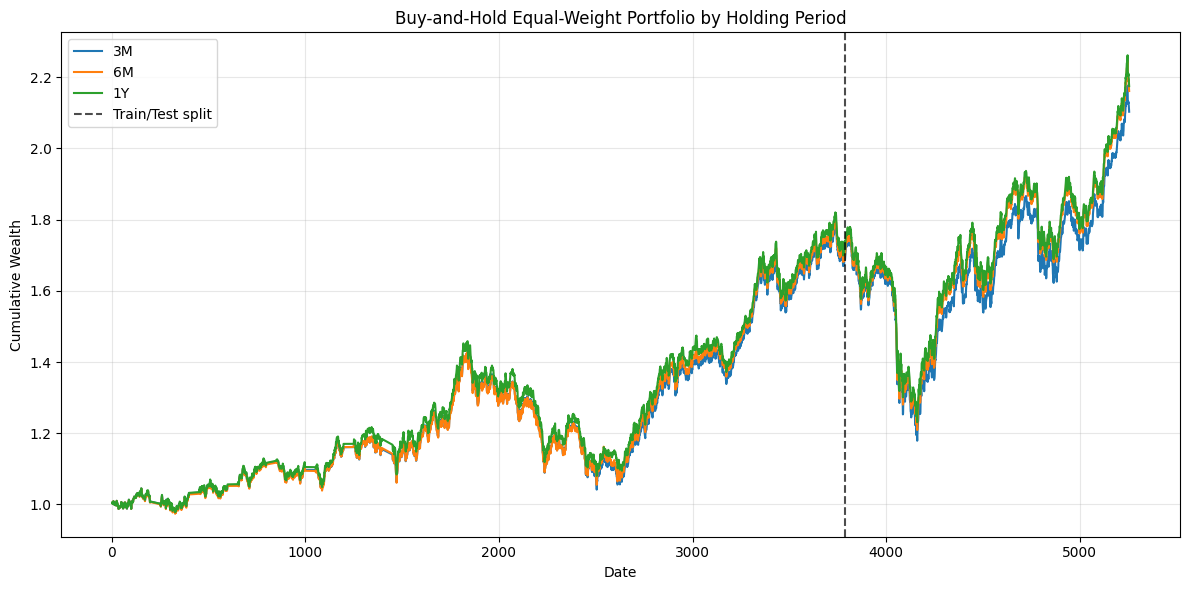

2    0.003981
3    0.002507
4   -0.004716
5    0.001613
6    0.001776
Name: buy_and_hold_equal_weight_252, dtype: float64

2    0.000000
3    0.000000
4   -0.004716
5   -0.003110
6   -0.001339
Name: buy_and_hold_equal_weight_252, dtype: float64

In [22]:
# Buy and Hold Strategy

simple_ret = np.expm1(log_ret)

annualization = 252
rolling_sharpe_window = 63
train_ratio = 0.7
split_idx = int(len(simple_ret) * train_ratio)
split_date = simple_ret.index[split_idx - 1]

holding_period_map = {
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

def compute_bh_max_recovery_time(drawdown):
    drawdown = drawdown.dropna()
    if drawdown.empty:
        return np.nan

    max_recovery = 0
    underwater_start = None

    for i, dd in enumerate(drawdown):
        if dd < 0 and underwater_start is None:
            underwater_start = i
        elif dd >= 0 and underwater_start is not None:
            max_recovery = max(max_recovery, i - underwater_start)
            underwater_start = None

    if underwater_start is not None:
        max_recovery = max(max_recovery, len(drawdown) - 1 - underwater_start)

    return int(max_recovery)

def compute_bh_annual_turnover(turnover_series, annualization=252):
    if turnover_series is None:
        return np.nan

    turnover_series = turnover_series.dropna()
    if turnover_series.empty:
        return 0.0

    return float(turnover_series.mean() * annualization)

def compute_bh_rolling_sharpe_stability(port_ret, annualization=252, rf_annual=0.03, window=63):
    port_ret = port_ret.dropna()
    if len(port_ret) < window:
        return np.nan

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    rolling_mean = excess_ret.rolling(window=window, min_periods=window).mean()
    rolling_std = excess_ret.rolling(window=window, min_periods=window).std(ddof=1)
    rolling_sharpe = np.sqrt(annualization) * rolling_mean / rolling_std.replace(0, np.nan)
    rolling_sharpe = rolling_sharpe.dropna()

    if rolling_sharpe.empty:
        return np.nan

    return float((rolling_sharpe > 0).mean())

def compute_bh_t_statistic(port_ret, annualization=252, rf_annual=0.03):
    port_ret = port_ret.dropna()
    if len(port_ret) < 2:
        return np.nan

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    vol_daily = excess_ret.std(ddof=1)

    if np.isclose(vol_daily, 0):
        return np.nan

    return float(excess_ret.mean() / (vol_daily / np.sqrt(len(excess_ret))))

def compute_bh_metrics(port_ret, annualization=252, rf_annual=0.03, turnover_series=None, rolling_window=63):
    port_ret = port_ret.dropna()

    if port_ret.empty:
        metrics = {
            "start": pd.NaT,
            "end": pd.NaT,
            "n_days": 0,
            "total_return": np.nan,
            "mean_return": np.nan,
            "annual_return": np.nan,
            "annual_vol": np.nan,
            "sharpe_ratio": np.nan,
            "sortino_ratio": np.nan,
            "max_drawdown": np.nan,
            "annual_turnover": np.nan,
            "max_recovery_time_days": np.nan,
            "rolling_sharpe_stability": np.nan,
            "t_statistic": np.nan,
        }
        return metrics, pd.Series(dtype=float), pd.Series(dtype=float)

    wealth = (1 + port_ret).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    mean_daily = port_ret.mean()
    vol_daily = port_ret.std(ddof=1)

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    mean_excess_daily = excess_ret.mean()

    downside = np.minimum(port_ret, 0)
    downside_dev = np.sqrt((downside ** 2).mean())

    sharpe = np.nan if np.isclose(vol_daily, 0) else (mean_excess_daily / vol_daily) * np.sqrt(annualization)
    sortino = np.nan if np.isclose(downside_dev, 0) else (mean_daily / downside_dev) * np.sqrt(annualization)

    metrics = {
        "start": port_ret.index[0],
        "end": port_ret.index[-1],
        "n_days": len(port_ret),
        "total_return": wealth.iloc[-1] - 1,
        "mean_return": mean_daily * annualization,
        "annual_return": wealth.iloc[-1] ** (annualization / len(port_ret)) - 1,
        "annual_vol": vol_daily * np.sqrt(annualization),
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": drawdown.min(),
        "annual_turnover": compute_bh_annual_turnover(turnover_series, annualization=annualization),
        "max_recovery_time_days": compute_bh_max_recovery_time(drawdown),
        "rolling_sharpe_stability": compute_bh_rolling_sharpe_stability(port_ret, annualization=annualization, rf_annual=rf_annual, window=rolling_window),
        "t_statistic": compute_bh_t_statistic(port_ret, annualization=annualization, rf_annual=rf_annual),
    }

    return metrics, wealth, drawdown

def backtest_buy_and_hold(simple_returns, holding_period, annualization=252):
    simple_returns = simple_returns.dropna(how="any").copy()

    n_assets = simple_returns.shape[1]
    target_weights = pd.Series(
        np.repeat(1 / n_assets, n_assets),
        index=simple_returns.columns,
        name="target_weight"
    )

    current_weights = target_weights.copy()
    portfolio_returns = []
    weights_history = []
    turnover_history = []

    for t, date in enumerate(simple_returns.index):
        if t == 0 or t % holding_period == 0:
            trade_weights = target_weights.copy()
            turnover = 0.0 if t == 0 else 0.5 * np.abs(trade_weights - current_weights).sum()
        else:
            trade_weights = current_weights.copy()
            turnover = 0.0

        day_ret = simple_returns.loc[date].fillna(0.0)
        realized_ret = float(np.dot(trade_weights.values, day_ret.values))

        portfolio_returns.append((date, realized_ret))
        weights_history.append(pd.Series(trade_weights, name=date))
        turnover_history.append((date, float(turnover)))

        position_values = trade_weights * (1 + day_ret)
        denom = position_values.sum()
        current_weights = trade_weights if np.isclose(denom, 0) else position_values / denom

    port_ret = pd.Series(
        [x[1] for x in portfolio_returns],
        index=[x[0] for x in portfolio_returns],
        name=f"buy_and_hold_equal_weight_{holding_period}"
    )
    weights_df = pd.DataFrame(weights_history)
    turnover_series = pd.Series(
        [x[1] for x in turnover_history],
        index=[x[0] for x in turnover_history],
        name="turnover"
    )

    metrics, wealth, drawdown = compute_bh_metrics(
        port_ret,
        annualization=annualization,
        turnover_series=turnover_series,
        rolling_window=rolling_sharpe_window,
    )

    return {
        "target_weights": target_weights,
        "weights": weights_df,
        "turnover": turnover_series,
        "portfolio_returns": port_ret,
        "wealth": wealth,
        "drawdown": drawdown,
        "metrics": metrics,
        "holding_period": holding_period,
    }

def evaluate_bh_train_test(res, split_date):
    port_ret = res["portfolio_returns"].dropna()
    turnover_series = res["turnover"].reindex(port_ret.index).fillna(0.0)

    train_mask = port_ret.index <= split_date
    test_mask = port_ret.index > split_date

    train_metrics, train_wealth, train_drawdown = compute_bh_metrics(
        port_ret.loc[train_mask],
        annualization=annualization,
        turnover_series=turnover_series.loc[train_mask],
        rolling_window=rolling_sharpe_window,
    )
    test_metrics, test_wealth, test_drawdown = compute_bh_metrics(
        port_ret.loc[test_mask],
        annualization=annualization,
        turnover_series=turnover_series.loc[test_mask],
        rolling_window=rolling_sharpe_window,
    )

    return {
        "IS": train_metrics,
        "OOS": test_metrics,
        "IS_wealth": train_wealth,
        "OOS_wealth": test_wealth,
        "IS_drawdown": train_drawdown,
        "OOS_drawdown": test_drawdown,
    }

def build_bh_metric_row(metrics):
    return {
        "Sharpe": metrics.get("sharpe_ratio", np.nan),
        "Mean Return": metrics.get("mean_return", np.nan),
        "Max Drawdown": metrics.get("max_drawdown", np.nan),
        "Annual Turnover": metrics.get("annual_turnover", np.nan),
        "Max Recovery Time": metrics.get("max_recovery_time_days", np.nan),
        "Rolling Sharpe stability": metrics.get("rolling_sharpe_stability", np.nan),
        "t-statistic": metrics.get("t_statistic", np.nan),
    }

metric_formatters = {
    "Sharpe": "{:.3f}",
    "Mean Return": "{:.2%}",
    "Max Drawdown": "{:.2%}",
    "Annual Turnover": "{:.1%}",
    "Max Recovery Time": "{:.0f} days",
    "Rolling Sharpe stability": "{:.3f}",
    "t-statistic": "{:.2f}",
}

bh_grid_results = {}
bh_evaluations = {}
bh_train_metrics_table = []

for label, holding_period in holding_period_map.items():
    res = backtest_buy_and_hold(
        simple_returns=simple_ret,
        holding_period=holding_period,
        annualization=annualization,
    )
    eval_res = evaluate_bh_train_test(res, split_date)

    bh_grid_results[label] = res
    bh_evaluations[label] = eval_res

    row = {
        "Holding Period": label,
        "Holding Days": holding_period,
        "Train Days": eval_res["IS"].get("n_days", 0),
    }
    row.update(build_bh_metric_row(eval_res["IS"]))
    bh_train_metrics_table.append(row)

bh_train_metrics_df = pd.DataFrame(bh_train_metrics_table).sort_values("Holding Days").reset_index(drop=True)

best_bh_train_row = bh_train_metrics_df.sort_values("Sharpe", ascending=False).iloc[0]
best_bh_key = best_bh_train_row["Holding Period"]
best_bh_res = bh_grid_results[best_bh_key]
best_bh_eval = bh_evaluations[best_bh_key]
bh_results = best_bh_res

bh_test_metrics_df = pd.DataFrame([
    {
        "Selected Holding Period": best_bh_key,
        "Holding Days": holding_period_map[best_bh_key],
        "Test Days": best_bh_eval["OOS"].get("n_days", 0),
        **build_bh_metric_row(best_bh_eval["OOS"]),
    }
])

print("Train/Test split:", simple_ret.index[0], "to", split_date, "|", simple_ret.index[split_idx], "to", simple_ret.index[-1])
print("Buy & Hold train performance for all holding periods")
display(bh_train_metrics_df.style.format({**metric_formatters, "Holding Days": "{:.0f}", "Train Days": "{:.0f}"}))

print("Best Buy & Hold holding period selected by train Sharpe:", best_bh_key)
print("Buy & Hold test performance for selected holding period")
display(bh_test_metrics_df.style.format({**metric_formatters, "Holding Days": "{:.0f}", "Test Days": "{:.0f}"}))

display(best_bh_res["target_weights"].to_frame())
display(best_bh_res["weights"].tail())

plt.figure(figsize=(12, 6))
for label, res in bh_grid_results.items():
    if not res["wealth"].empty:
        plt.plot(res["wealth"].index, res["wealth"], label=label)
plt.axvline(split_date, color="black", linestyle="--", alpha=0.7, label="Train/Test split")
plt.title("Buy-and-Hold Equal-Weight Portfolio by Holding Period")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(best_bh_res["portfolio_returns"].head())
display(best_bh_res["drawdown"].head())


Buy and Hold 전략은 동일 가중으로 첫날 모든 종목을 구매한 뒤, 기간이 끝날때 까지 보유하고 있는 전략이다.

The Buy and Hold strategy is a strategy where all assets are purchased on the first day with equal weighting and held until the end of the period.

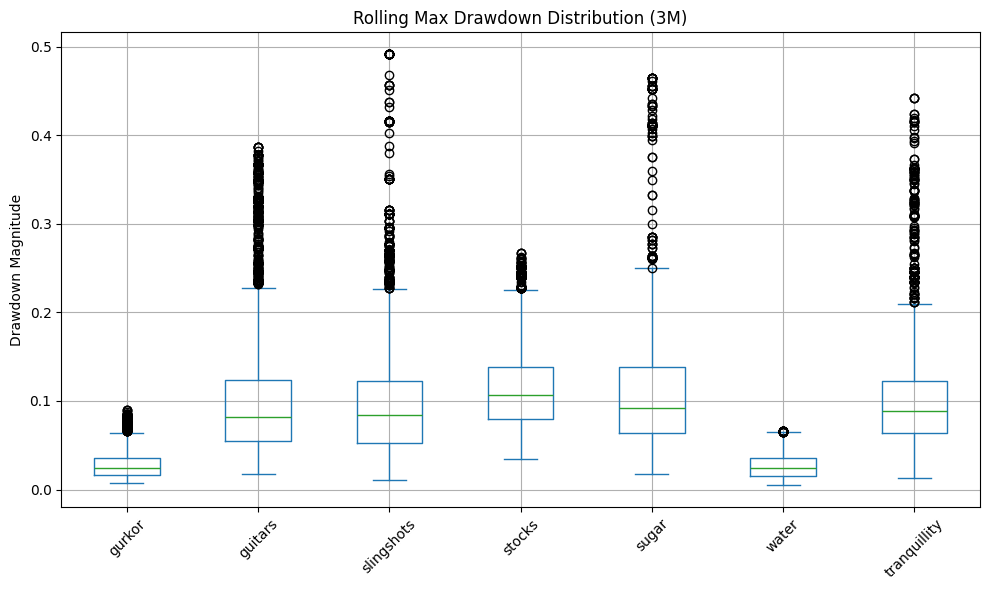

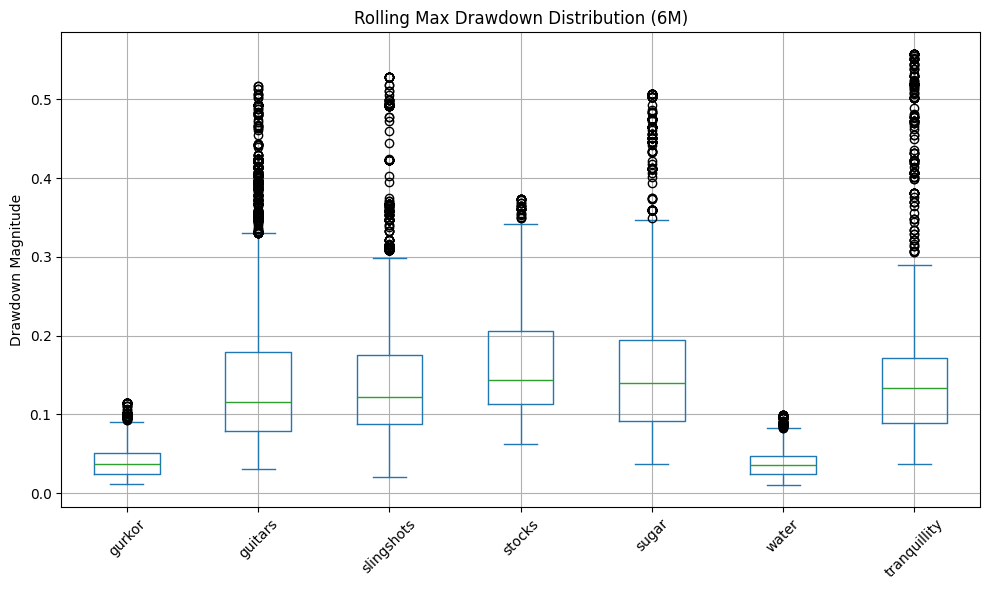

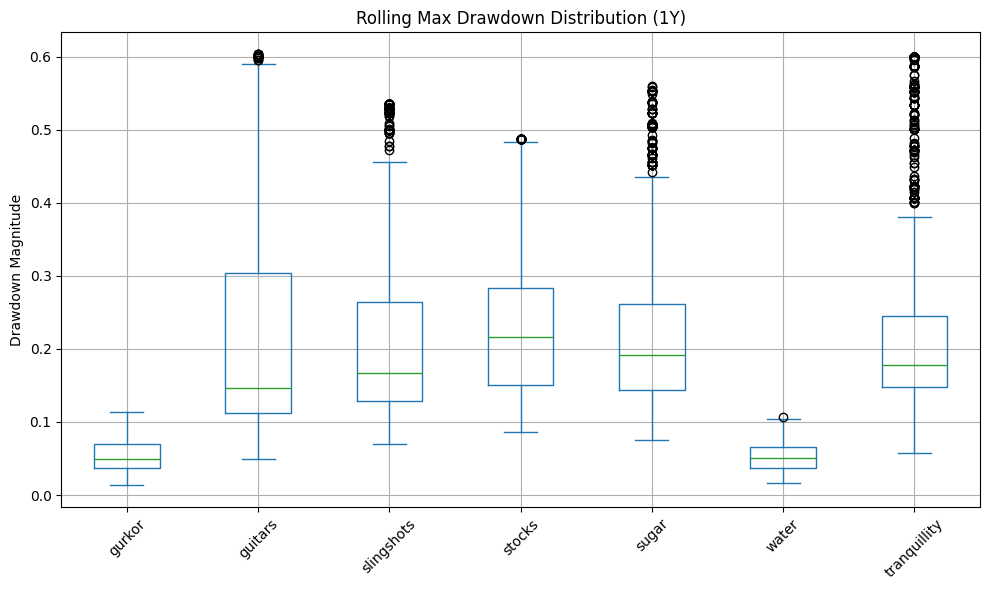

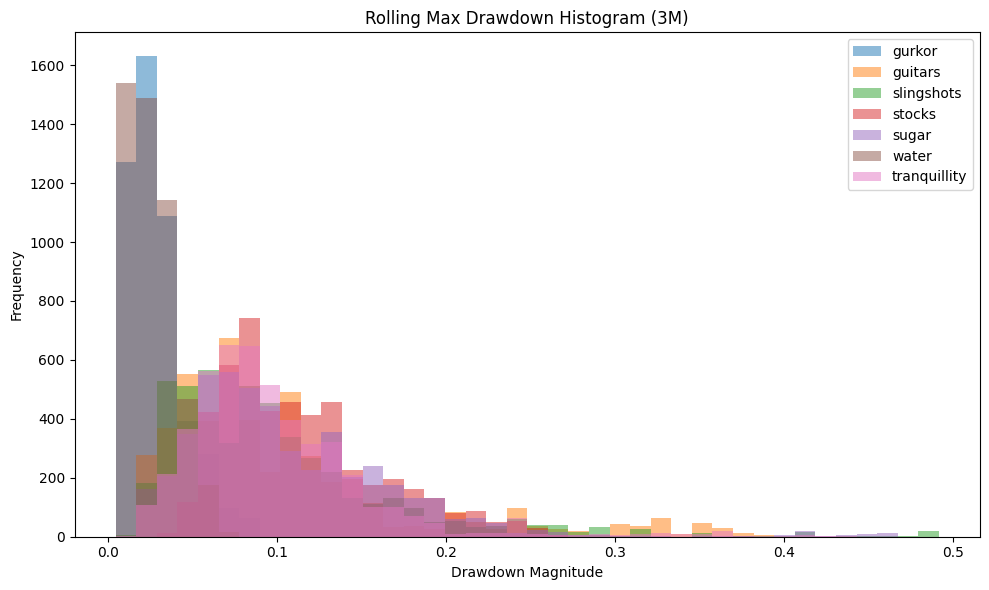

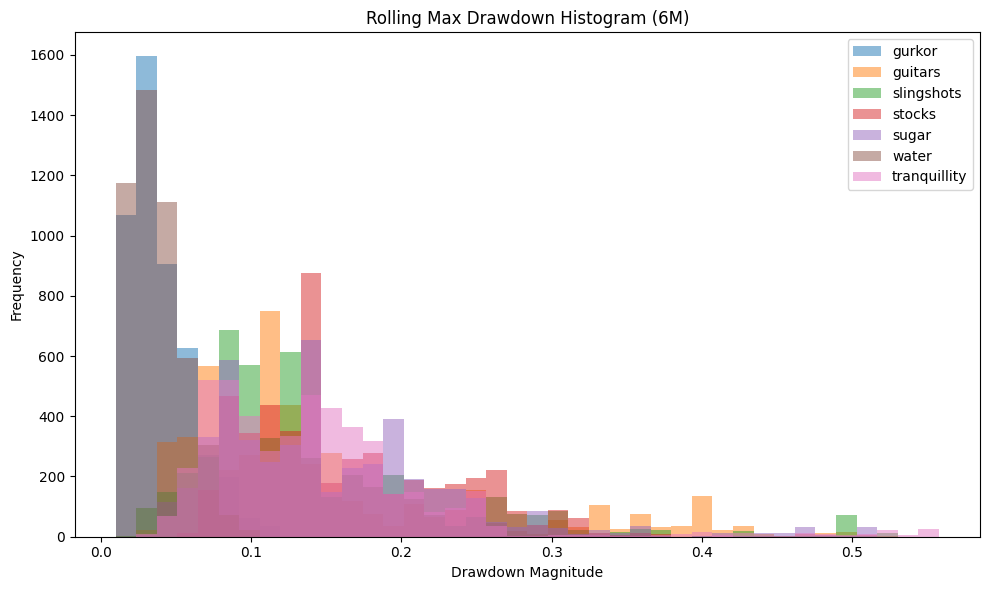

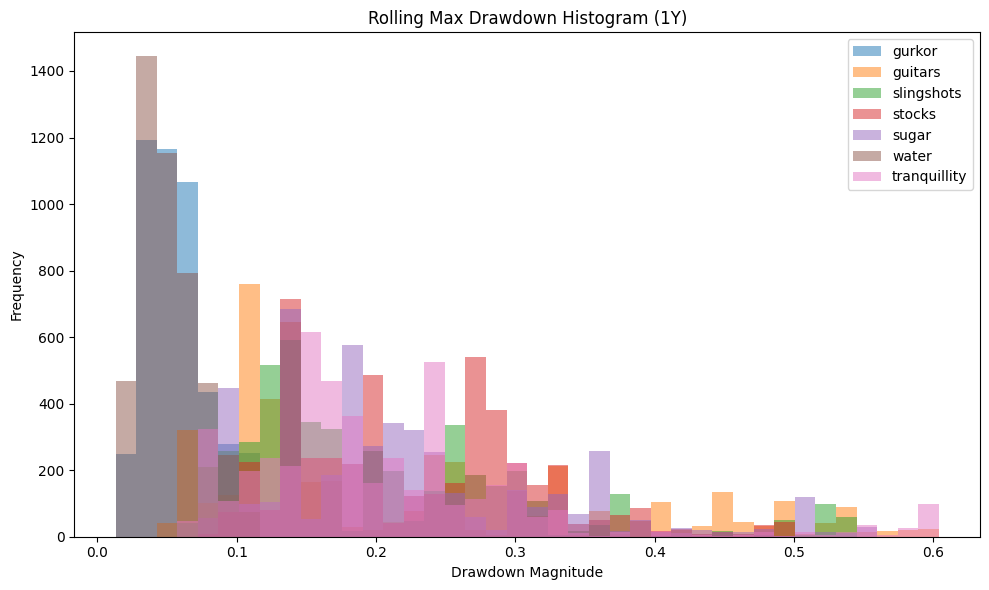

In [23]:
# Buy the dip strategy PreProcessing

simple_ret = np.expm1(log_ret)

window_map = {
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

# rolling max drawdown Function
def rolling_max_drawdown(ret_series, window):
    def calc_mdd(x):
        wealth = np.cumprod(1 + x)
        running_max = np.maximum.accumulate(wealth)
        drawdown = wealth / running_max - 1
        return drawdown.min()   # Negative number

    return ret_series.rolling(window=window, min_periods=window).apply(calc_mdd, raw=True)


rolling_mdd_dict = {}
rolling_dip_dict = {}

for label, window in window_map.items():
    mdd_df = pd.DataFrame(index=simple_ret.index)

    for col in simple_ret.columns:
        mdd_df[col] = rolling_max_drawdown(simple_ret[col], window)

    rolling_mdd_dict[label] = mdd_df
    rolling_dip_dict[label] = -mdd_df 

summary_rows = []

for label, dip_df in rolling_dip_dict.items():
    for asset in dip_df.columns:
        s = dip_df[asset].dropna()

        summary_rows.append({
            "window": label,
            "asset": asset,
            "count": len(s),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p10": s.quantile(0.10),
            "p25": s.quantile(0.25),
            "median": s.quantile(0.50),
            "p75": s.quantile(0.75),
            "p90": s.quantile(0.90),
            "max": s.max(),
        })

mdd_summary_df = (
    pd.DataFrame(summary_rows)
    .set_index(["window", "asset"])
    .sort_index()
)

display(
    mdd_summary_df.style.format({
        "mean": "{:.2%}",
        "std": "{:.2%}",
        "min": "{:.2%}",
        "p10": "{:.2%}",
        "p25": "{:.2%}",
        "median": "{:.2%}",
        "p75": "{:.2%}",
        "p90": "{:.2%}",
        "max": "{:.2%}",
    })
)


for label, dip_df in rolling_dip_dict.items():
    plt.figure(figsize=(10, 6))
    dip_df.plot(kind="box", ax=plt.gca(), grid=True)
    plt.title(f"Rolling Max Drawdown Distribution ({label})")
    plt.ylabel("Drawdown Magnitude")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


for label, dip_df in rolling_dip_dict.items():
    dip_df.plot(
        kind="hist",
        bins=40,
        alpha=0.5,
        figsize=(10, 6),
        title=f"Rolling Max Drawdown Histogram ({label})"
    )
    plt.xlabel("Drawdown Magnitude")
    plt.tight_layout()
    plt.show()

,window,quantile,alpha,beta,K,start,end,n_days,total_return,mean_return,annual_return,annual_vol,sharpe_ratio,sortino_ratio,max_drawdown,annual_turnover,max_recovery_time_days,rolling_sharpe_stability,t_statistic
0,1Y,70%,0.50,0.40,3,367,5256,4576,201.52%,7.47%,6.27%,16.69%,0.271,0.630,-52.05%,17.1%,1890,0.606,1.15
1,1Y,70%,0.50,0.60,3,367,5256,4576,176.01%,7.01%,5.75%,16.83%,0.241,0.584,-48.51%,18.2%,1577,0.599,1.03
2,1Y,70%,1.00,0.40,3,367,5256,4576,207.31%,7.79%,6.38%,17.94%,0.270,0.613,-56.42%,17.8%,2788,0.608,1.15
3,1Y,70%,1.00,0.60,3,367,5256,4576,197.04%,7.73%,6.18%,18.62%,0.257,0.584,-53.18%,17.7%,1779,0.603,1.09
4,1Y,90%,0.50,0.40,3,367,5256,4576,183.88%,7.66%,5.91%,19.57%,0.241,0.552,-55.94%,7.5%,1856,0.607,1.03
5,1Y,90%,0.50,0.60,3,367,5256,4576,191.66%,7.92%,6.07%,20.10%,0.247,0.556,-56.55%,7.7%,1839,0.609,1.05
6,1Y,90%,1.00,0.40,3,367,5256,4576,187.76%,7.76%,5.99%,19.68%,0.244,0.556,-56.60%,9.4%,1863,0.608,1.04
7,1Y,90%,1.00,0.60,3,367,5256,4576,189.08%,7.60%,6.02%,18.71%,0.248,0.574,-57.27%,12.0%,1891,0.605,1.06
8,3M,70%,0.50,0.40,3,127,5256,4765,131.24%,5.86%,4.53%,16.88%,0.172,0.487,-50.92%,27.6%,992,0.588,0.75
9,3M,70%,0.50,0.60,3,127,5256,4765,126.45%,5.89%,4.42%,17.66%,0.166,0.467,-53.97%,24.8%,989,0.586,0.72


,window,quantile,alpha,beta,K,start,end,n_days,total_return,mean_return,annual_return,annual_vol,sharpe_ratio,sortino_ratio,max_drawdown,annual_turnover,max_recovery_time_days,rolling_sharpe_stability,t_statistic
0,1Y,70%,0.50,0.40,3,367,5256,4576,201.52%,7.47%,6.27%,16.69%,0.271,0.630,-52.05%,17.1%,1890,0.606,1.15
2,1Y,70%,1.00,0.40,3,367,5256,4576,207.31%,7.79%,6.38%,17.94%,0.270,0.613,-56.42%,17.8%,2788,0.608,1.15
12,3M,90%,0.50,0.40,3,127,5256,4765,195.63%,6.72%,5.90%,14.08%,0.268,0.675,-47.11%,20.6%,2854,0.614,1.16
3,1Y,70%,1.00,0.60,3,367,5256,4576,197.04%,7.73%,6.18%,18.62%,0.257,0.584,-53.18%,17.7%,1779,0.603,1.09
7,1Y,90%,1.00,0.60,3,367,5256,4576,189.08%,7.60%,6.02%,18.71%,0.248,0.574,-57.27%,12.0%,1891,0.605,1.06
5,1Y,90%,0.50,0.60,3,367,5256,4576,191.66%,7.92%,6.07%,20.10%,0.247,0.556,-56.55%,7.7%,1839,0.609,1.05
6,1Y,90%,1.00,0.40,3,367,5256,4576,187.76%,7.76%,5.99%,19.68%,0.244,0.556,-56.60%,9.4%,1863,0.608,1.04
23,6M,90%,1.00,0.60,3,190,5256,4702,187.57%,7.18%,5.82%,17.40%,0.243,0.580,-49.38%,12.8%,1522,0.615,1.05
1,1Y,70%,0.50,0.60,3,367,5256,4576,176.01%,7.01%,5.75%,16.83%,0.241,0.584,-48.51%,18.2%,1577,0.599,1.03
4,1Y,90%,0.50,0.40,3,367,5256,4576,183.88%,7.66%,5.91%,19.57%,0.241,0.552,-55.94%,7.5%,1856,0.607,1.03


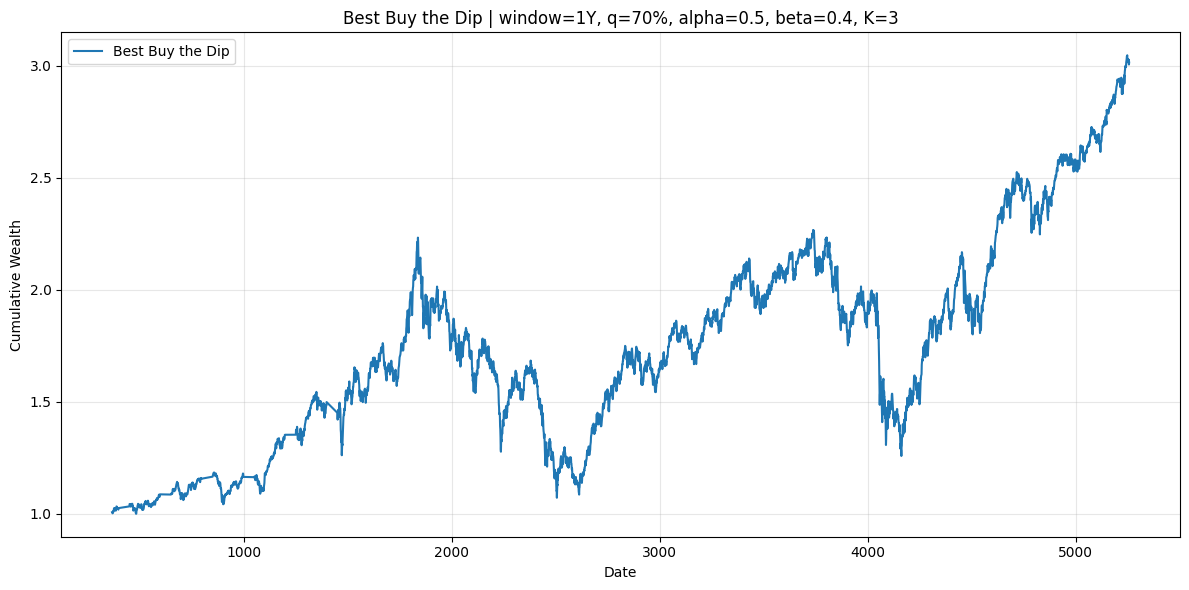

Best strategy key: ('1Y', np.float64(0.7), np.float64(0.5), np.float64(0.4))


,OOS
Sharpe,0.271
Mean Return,7.47%
Max Drawdown,-52.05%
Annual Turnover,17.1%
Max Recovery Time,1890 days
Rolling Sharpe stability,0.606
t-statistic,1.15


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
5252,7.198615e-14,0.033296,0.501098,0.068978,1.186171e-60,0.373257,0.023371
5253,7.132604e-14,0.033533,0.504461,0.068265,1.202650e-60,0.370325,0.023416
5254,7.173215e-14,0.033284,0.503459,0.068316,1.203706e-60,0.371279,0.023662
5255,7.142531e-14,0.033371,0.504242,0.067789,1.148795e-60,0.370445,0.024153
5256,7.178666e-14,0.033328,0.501995,0.067624,1.162768e-60,0.372754,0.024300


5252    0.000000e+00
5253    0.000000e+00
5254    0.000000e+00
5255    9.714451e-17
5256    9.540979e-17
Name: turnover, dtype: float64

367    0.006447
368   -0.001619
369   -0.003707
370    0.004079
371   -0.000096
Name: buy_the_dip_quantile, dtype: float64

367    0.000000
368   -0.001619
369   -0.005319
370   -0.001262
371   -0.001358
Name: buy_the_dip_quantile, dtype: float64

,rebalance_date,applied_date,n_buy,n_sell,buy_assets,sell_assets,Delta_desired,Delta_exec,rho,capacity
0,366,367,5,2,"guitars, slingshots, sugar, water, tranquillity","gurkor, stocks",0.348325,0.114286,0.328101,0.285714
1,367,368,5,2,"gurkor, guitars, slingshots, sugar, water","tranquillity, stocks",0.316170,0.068058,0.215257,0.170145
2,368,369,5,2,"gurkor, guitars, slingshots, sugar, water","tranquillity, stocks",0.316170,0.040666,0.128620,0.101664
3,369,370,5,2,"guitars, slingshots, sugar, water, tranquillity","gurkor, stocks",0.348325,0.024406,0.070067,0.061015
4,370,371,5,2,"gurkor, guitars, slingshots, sugar, water","tranquillity, stocks",0.316170,0.014701,0.046496,0.036752


In [24]:
# Buy the Dip Strategy

simple_ret = np.expm1(log_ret)

window_map = {
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

quantile_levels = [0.70, 0.90]
alpha_grid = [1.0, 0.5]
beta_grid = [0.4, 0.6]

K = 3
annualization = 252
min_threshold_obs = 60
rolling_sharpe_window = 63

def compute_max_recovery_time(drawdown):
    drawdown = drawdown.dropna()
    if drawdown.empty:
        return np.nan

    max_recovery = 0
    underwater_start = None

    for i, dd in enumerate(drawdown):
        if dd < 0 and underwater_start is None:
            underwater_start = i
        elif dd >= 0 and underwater_start is not None:
            max_recovery = max(max_recovery, i - underwater_start)
            underwater_start = None

    if underwater_start is not None:
        max_recovery = max(max_recovery, len(drawdown) - 1 - underwater_start)

    return int(max_recovery)

def compute_annual_turnover(turnover_series, annualization=252):
    if turnover_series is None:
        return np.nan

    turnover_series = turnover_series.dropna()
    if turnover_series.empty:
        return 0.0

    return float(turnover_series.mean() * annualization)

def compute_rolling_sharpe_stability(port_ret, annualization=252, rf_annual=0.03, window=63):
    port_ret = port_ret.dropna()
    if len(port_ret) < window:
        return np.nan

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    rolling_mean = excess_ret.rolling(window=window, min_periods=window).mean()
    rolling_std = excess_ret.rolling(window=window, min_periods=window).std(ddof=1)
    rolling_sharpe = np.sqrt(annualization) * rolling_mean / rolling_std.replace(0, np.nan)
    rolling_sharpe = rolling_sharpe.dropna()

    if rolling_sharpe.empty:
        return np.nan

    # Stability is defined here as the fraction of rolling Sharpe windows that remain positive.
    return float((rolling_sharpe > 0).mean())

def compute_t_statistic(port_ret, annualization=252, rf_annual=0.03):
    port_ret = port_ret.dropna()
    if len(port_ret) < 2:
        return np.nan

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    vol_daily = excess_ret.std(ddof=1)

    if np.isclose(vol_daily, 0):
        return np.nan

    return float(excess_ret.mean() / (vol_daily / np.sqrt(len(excess_ret))))

#  Performance Function
def compute_metrics(port_ret, annualization=252, rf_annual=0.03, turnover_series=None, rolling_window=63):
    port_ret = port_ret.dropna()

    if port_ret.empty:
        metrics = {
            "start": pd.NaT,
            "end": pd.NaT,
            "n_days": 0,
            "total_return": np.nan,
            "mean_return": np.nan,
            "annual_return": np.nan,
            "annual_vol": np.nan,
            "sharpe_ratio": np.nan,
            "sortino_ratio": np.nan,
            "max_drawdown": np.nan,
            "annual_turnover": np.nan,
            "max_recovery_time_days": np.nan,
            "rolling_sharpe_stability": np.nan,
            "t_statistic": np.nan,
        }
        return metrics, pd.Series(dtype=float), pd.Series(dtype=float)

    wealth = (1 + port_ret).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    mean_daily = port_ret.mean()
    vol_daily = port_ret.std(ddof=1)

    rf_daily = (1 + rf_annual) ** (1 / annualization) - 1
    excess_ret = port_ret - rf_daily
    mean_excess_daily = excess_ret.mean()

    downside = np.minimum(port_ret, 0)
    downside_dev = np.sqrt((downside ** 2).mean())

    sharpe = np.nan if np.isclose(vol_daily, 0) else (mean_excess_daily / vol_daily) * np.sqrt(annualization)
    sortino = np.nan if np.isclose(downside_dev, 0) else (mean_daily / downside_dev) * np.sqrt(annualization)
    annual_turnover = compute_annual_turnover(turnover_series, annualization=annualization)
    max_recovery_time = compute_max_recovery_time(drawdown)
    rolling_sharpe_stability = compute_rolling_sharpe_stability(
        port_ret,
        annualization=annualization,
        rf_annual=rf_annual,
        window=rolling_window,
    )
    t_statistic = compute_t_statistic(port_ret, annualization=annualization, rf_annual=rf_annual)

    metrics = {
        "start": port_ret.index[0],
        "end": port_ret.index[-1],
        "n_days": len(port_ret),
        "total_return": wealth.iloc[-1] - 1,
        "mean_return": mean_daily * annualization,
        "annual_return": wealth.iloc[-1] ** (annualization / len(port_ret)) - 1,
        "annual_vol": vol_daily * np.sqrt(annualization),
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": drawdown.min(),
        "annual_turnover": annual_turnover,
        "max_recovery_time_days": max_recovery_time,
        "rolling_sharpe_stability": rolling_sharpe_stability,
        "t_statistic": t_statistic,
    }

    return metrics, wealth, drawdown

#  rolling dip(= -drawdown) 
def rolling_dip_magnitude(ret_series, window):
    def calc_dip(x):
        wealth = np.concatenate([[1.0], np.cumprod(1 + x)])
        running_max = np.maximum.accumulate(wealth)
        drawdown = wealth / running_max - 1
        return -drawdown.min()   # Postive number
    return ret_series.rolling(window=window, min_periods=window).apply(calc_dip, raw=True)

rolling_dip_dict = {}

for label, window in window_map.items():
    dip_df = pd.DataFrame(index=simple_ret.index)
    for col in simple_ret.columns:
        dip_df[col] = rolling_dip_magnitude(simple_ret[col], window)
    rolling_dip_dict[label] = dip_df

#  threshold: historic dip distribution of qauntile 
threshold_dict = {}
cap_dict = {}

for label, dip_df in rolling_dip_dict.items():
    cap_dict[label] = dip_df.expanding(min_periods=min_threshold_obs).max().shift(1)

    for q in quantile_levels:
        threshold_dict[(label, q)] = (
            dip_df.expanding(min_periods=min_threshold_obs)
            .quantile(q)
            .shift(1)
        )

# Buy the Dip
def backtest_buy_the_dip_quantile(
    simple_returns,
    dip_df,
    buy_threshold_df,
    alpha,
    beta,
    K=3,
    annualization=252
):
    assets = simple_returns.columns.tolist()
    n_assets = len(assets)

    w_pre = pd.Series(np.repeat(1 / n_assets, n_assets), index=assets, dtype=float)

    portfolio_returns = []
    weights_history = []
    turnover_history = []
    trade_log = []

    for t in range(len(simple_returns) - 1):
        date_t = simple_returns.index[t]
        date_next = simple_returns.index[t + 1]

        dip_t = dip_df.iloc[t]
        d_buy_t = buy_threshold_df.iloc[t]

        valid_mask = dip_t.notna() & d_buy_t.notna()
        if valid_mask.sum() < 2:
            continue

        dip_t = dip_t.loc[valid_mask]
        d_buy_t = d_buy_t.loc[valid_mask]

        # buy assets: dip >= quantile threshold
        buy_assets = dip_t.index[dip_t >= d_buy_t].tolist()

        # sell assets: assets with the smallest dip among non-buyers
        non_buy_dip = dip_t.loc[~dip_t.index.isin(buy_assets)]
        sell_assets = non_buy_dip.sort_values(ascending=True).head(min(K, len(non_buy_dip))).index.tolist()

        # delta_desired_i = alpha * min(max(0, dip - d_buy), d_cap - d_buy)
        delta_desired = pd.Series(0.0, index=assets)

        if len(buy_assets) > 0:
            delta_desired.loc[buy_assets] = alpha * np.minimum(dip_t.loc[buy_assets], 0.2)

        Delta_desired = float(delta_desired.sum())

        # selling capacity
        if len(sell_assets) > 0:
            C_t = len(sell_assets) * float(w_pre.loc[sell_assets].min())
        else:
            C_t = 0.0

        # execute only beta fraction
        if Delta_desired > 0 and C_t > 0:
            Delta_exec = min(Delta_desired, beta * C_t)
            rho = Delta_exec / Delta_desired
        else:
            Delta_exec = 0.0
            rho = 0.0

        delta_exec = rho * delta_desired

        # update weights
        w_new = w_pre.copy()

        if Delta_exec > 0 and len(sell_assets) > 0:
            w_new.loc[buy_assets] = w_new.loc[buy_assets] + delta_exec.loc[buy_assets]
            w_new.loc[sell_assets] = w_new.loc[sell_assets] - (Delta_exec / len(sell_assets))

        # numerical safety only
        w_new = w_new.clip(lower=0)
        w_new = w_new / w_new.sum()
        turnover = 0.5 * np.abs(w_new - w_pre).sum()

        # apply to next-day return
        next_ret = simple_returns.iloc[t + 1]
        realized_ret = float(np.dot(w_new.values, next_ret.values))

        portfolio_returns.append((date_next, realized_ret))
        weights_history.append(pd.Series(w_new, name=date_next))
        turnover_history.append((date_next, float(turnover)))

        trade_log.append({
            "rebalance_date": date_t,
            "applied_date": date_next,
            "n_buy": len(buy_assets),
            "n_sell": len(sell_assets),
            "buy_assets": ", ".join(buy_assets),
            "sell_assets": ", ".join(sell_assets),
            "Delta_desired": Delta_desired,
            "Delta_exec": Delta_exec,
            "rho": rho,
            "capacity": C_t
        })

        # drift to next pre-trade weights
        position_values = w_new * (1 + next_ret)
        w_pre = position_values / position_values.sum()

    port_ret = pd.Series(
        [x[1] for x in portfolio_returns],
        index=[x[0] for x in portfolio_returns],
        name="buy_the_dip_quantile"
    )

    weights_df = pd.DataFrame(weights_history)
    trade_log_df = pd.DataFrame(trade_log)
    turnover_series = pd.Series(
        [x[1] for x in turnover_history],
        index=[x[0] for x in turnover_history],
        name="turnover"
    )

    metrics, wealth, drawdown = compute_metrics(
        port_ret,
        annualization=annualization,
        turnover_series=turnover_series,
        rolling_window=rolling_sharpe_window,
    )

    return {
        "portfolio_returns": port_ret,
        "weights": weights_df,
        "turnover": turnover_series,
        "wealth": wealth,
        "drawdown": drawdown,
        "metrics": metrics,
        "trade_log": trade_log_df
    }


btd_grid_results = {}
btd_grid_metrics = []

for label in window_map.keys():
    dip_df = rolling_dip_dict[label]

    for q in quantile_levels:
        buy_threshold_df = threshold_dict[(label, q)]

        for alpha in alpha_grid:
            for beta in beta_grid:
                res = backtest_buy_the_dip_quantile(
                    simple_returns=simple_ret,
                    dip_df=dip_df,
                    buy_threshold_df=buy_threshold_df,
                    alpha=alpha,
                    beta=beta,
                    K=K,
                    annualization=annualization
                )

                key = (label, q, alpha, beta)
                btd_grid_results[key] = res

                row = {
                    "window": label,
                    "quantile": q,
                    "alpha": alpha,
                    "beta": beta,
                    "K": K
                }
                row.update(res["metrics"])
                btd_grid_metrics.append(row)

btd_grid_metrics_df = pd.DataFrame(btd_grid_metrics).sort_values(
    ["window", "quantile", "alpha", "beta"]
).reset_index(drop=True)

display(
    btd_grid_metrics_df.style.format({
        "quantile": "{:.0%}",
        "alpha": "{:.2f}",
        "beta": "{:.2f}",
        "total_return": "{:.2%}",
        "mean_return": "{:.2%}",
        "annual_return": "{:.2%}",
        "annual_vol": "{:.2%}",
        "sharpe_ratio": "{:.3f}",
        "sortino_ratio": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "annual_turnover": "{:.1%}",
        "max_recovery_time_days": "{:.0f}",
        "rolling_sharpe_stability": "{:.3f}",
        "t_statistic": "{:.2f}",
    })
)

# Sharpe ratio top 10
top10 = btd_grid_metrics_df.sort_values("sharpe_ratio", ascending=False).head(10)

display(
    top10.style.format({
        "quantile": "{:.0%}",
        "alpha": "{:.2f}",
        "beta": "{:.2f}",
        "total_return": "{:.2%}",
        "mean_return": "{:.2%}",
        "annual_return": "{:.2%}",
        "annual_vol": "{:.2%}",
        "sharpe_ratio": "{:.3f}",
        "sortino_ratio": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "annual_turnover": "{:.1%}",
        "max_recovery_time_days": "{:.0f}",
        "rolling_sharpe_stability": "{:.3f}",
        "t_statistic": "{:.2f}",
    })
)

def make_oos_metric_table(metrics, label="OOS"):
    def fmt(value, formatter):
        return "NaN" if pd.isna(value) else formatter(value)

    return pd.DataFrame(
        {
            label: [
                fmt(metrics.get("sharpe_ratio"), lambda x: f"{x:.3f}"),
                fmt(metrics.get("mean_return"), lambda x: f"{x:.2%}"),
                fmt(metrics.get("max_drawdown"), lambda x: f"{x:.2%}"),
                fmt(metrics.get("annual_turnover"), lambda x: f"{x:.1%}"),
                fmt(metrics.get("max_recovery_time_days"), lambda x: f"{int(x)} days"),
                fmt(metrics.get("rolling_sharpe_stability"), lambda x: f"{x:.3f}"),
                fmt(metrics.get("t_statistic"), lambda x: f"{x:.2f}"),
            ]
        },
        index=[
            "Sharpe",
            "Mean Return",
            "Max Drawdown",
            "Annual Turnover",
            "Max Recovery Time",
            "Rolling Sharpe stability",
            "t-statistic",
        ],
    )

# Best Sharpe ratio strategy Perfomance indication and Plot
best_row = btd_grid_metrics_df.sort_values("sharpe_ratio", ascending=False).iloc[0]
best_key = (
    best_row["window"],
    best_row["quantile"],
    best_row["alpha"],
    best_row["beta"]
)
best_res = btd_grid_results[best_key]
oos_metric_table = make_oos_metric_table(best_res["metrics"], label="OOS")

plt.figure(figsize=(12, 6))
plt.plot(best_res["wealth"].index, best_res["wealth"], label="Best Buy the Dip")
plt.title(
    f"Best Buy the Dip | "
    f"window={best_key[0]}, q={best_key[1]:.0%}, alpha={best_key[2]}, beta={best_key[3]}, K={K}"
)
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Best strategy key:", best_key)
display(oos_metric_table)
display(best_res["weights"].tail())
display(best_res["turnover"].tail())
display(best_res["portfolio_returns"].head())
display(best_res["drawdown"].head())
display(best_res["trade_log"].head())


,Strategy,Selected Model
0,Buy & Hold,Equal-weight static allocation
1,Minimum Variance Portfolio,Best Sharpe window = 1Y
2,Mean-Variance Portfolio,"Best Sharpe window = 1Y, risk_aversion = 1.0"
3,Buy the Dip,"window=1Y, q=70%, alpha=0.5, beta=0.4"


Common evaluation window: 367 to 5256 (4576 days)


,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic
Buy & Hold,0.196,4.67%,-32.37%,6.2%,1176 days,0.564,0.83
Minimum Variance Portfolio,0.320,4.24%,-8.98%,197.1%,488 days,0.574,1.36
Mean-Variance Portfolio,-0.078,1.90%,-44.43%,1745.6%,3412 days,0.479,-0.33
Buy the Dip,0.271,7.47%,-52.05%,17.1%,1890 days,0.606,1.15


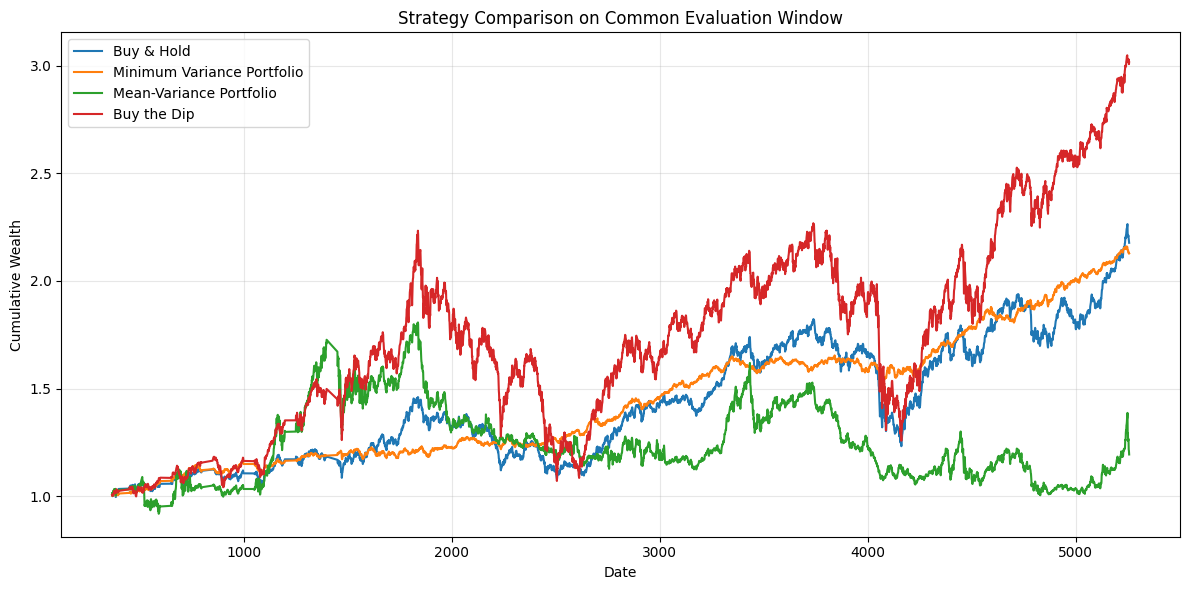

In [25]:
# Strategy comparison summary
def pick_best_result_by_sharpe(result_dict):
    best_key = None
    best_res = None
    best_score = -np.inf

    for key, res in result_dict.items():
        sharpe = res.get("metrics", {}).get("sharpe_ratio", np.nan)
        score = -np.inf if pd.isna(sharpe) else float(sharpe)
        if score > best_score:
            best_score = score
            best_key = key
            best_res = res

    return best_key, best_res

def compute_turnover_from_weights(weights_df, simple_returns):
    if weights_df is None or weights_df.empty:
        return pd.Series(dtype=float, name="turnover")

    weights = weights_df.copy().sort_index()
    weights = weights.reindex(columns=simple_returns.columns).fillna(0.0)
    turnovers = []

    for i, date in enumerate(weights.index):
        current_w = weights.iloc[i].fillna(0.0)

        if i == 0:
            turnovers.append(0.0)
            continue

        prev_date = weights.index[i - 1]
        prev_w = weights.iloc[i - 1].fillna(0.0)
        prev_ret = simple_returns.loc[prev_date].reindex(weights.columns).fillna(0.0)

        position_values = prev_w * (1 + prev_ret)
        denom = position_values.sum()
        w_pre = prev_w if np.isclose(denom, 0) else position_values / denom

        turnover = 0.5 * np.abs(current_w - w_pre).sum()
        turnovers.append(float(turnover))

    return pd.Series(turnovers, index=weights.index, name="turnover")

def build_metric_row(metrics):
    return {
        "Sharpe": metrics.get("sharpe_ratio", np.nan),
        "Mean Return": metrics.get("mean_return", np.nan),
        "Max Drawdown": metrics.get("max_drawdown", np.nan),
        "Annual Turnover": metrics.get("annual_turnover", np.nan),
        "Max Recovery Time": metrics.get("max_recovery_time_days", np.nan),
        "Rolling Sharpe stability": metrics.get("rolling_sharpe_stability", np.nan),
        "t-statistic": metrics.get("t_statistic", np.nan),
    }

best_btd_row = btd_grid_metrics_df.sort_values("sharpe_ratio", ascending=False).iloc[0]
best_btd_key = (
    best_btd_row["window"],
    best_btd_row["quantile"],
    best_btd_row["alpha"],
    best_btd_row["beta"],
)
best_btd_res = btd_grid_results[best_btd_key]

best_min_key, best_min_res = pick_best_result_by_sharpe(results)
best_mv_key, best_mv_res = pick_best_result_by_sharpe(mv_results)
best_mv_model_label = (
    f"Best Sharpe window = {best_mv_key[0]}, risk_aversion = {best_mv_key[1]}"
    if isinstance(best_mv_key, tuple)
    else f"Best Sharpe window = {best_mv_key}"
)

selected_strategy_specs = pd.DataFrame(
    [
        {"Strategy": "Buy & Hold", "Selected Model": "Equal-weight static allocation"},
        {"Strategy": "Minimum Variance Portfolio", "Selected Model": f"Best Sharpe window = {best_min_key}"},
        {"Strategy": "Mean-Variance Portfolio", "Selected Model": best_mv_model_label},
        {
            "Strategy": "Buy the Dip",
            "Selected Model": (
                f"window={best_btd_key[0]}, q={best_btd_key[1]:.0%}, "
                f"alpha={best_btd_key[2]}, beta={best_btd_key[3]}"
            ),
        },
    ]
)

raw_strategy_results = {
    "Buy & Hold": bh_results,
    "Minimum Variance Portfolio": best_min_res,
    "Mean-Variance Portfolio": best_mv_res,
    "Buy the Dip": best_btd_res,
}

common_index = None
for res in raw_strategy_results.values():
    idx = res["portfolio_returns"].dropna().index
    common_index = idx if common_index is None else common_index.intersection(idx)

common_index = common_index.sort_values()
common_simple_returns = simple_ret.loc[common_index]

strategy_compare_results = {}

for strategy_name, res in raw_strategy_results.items():
    port_ret = res["portfolio_returns"].reindex(common_index).dropna()

    if "turnover" in res and isinstance(res["turnover"], pd.Series) and not res["turnover"].empty:
        turnover_series = res["turnover"].reindex(port_ret.index).fillna(0.0)
    elif "weights" in res:
        turnover_series = compute_turnover_from_weights(
            res["weights"].reindex(port_ret.index),
            common_simple_returns,
        ).reindex(port_ret.index).fillna(0.0)
    else:
        turnover_series = pd.Series(0.0, index=port_ret.index, name="turnover")

    metrics, wealth, drawdown = compute_metrics(
        port_ret,
        annualization=annualization,
        turnover_series=turnover_series,
        rolling_window=rolling_sharpe_window,
    )

    strategy_compare_results[strategy_name] = {
        "metrics": metrics,
        "wealth": wealth,
        "drawdown": drawdown,
        "turnover": turnover_series,
    }

strategy_metric_table = pd.DataFrame(
    {name: build_metric_row(res["metrics"]) for name, res in strategy_compare_results.items()}
).T

display(selected_strategy_specs)
print("Common evaluation window:", common_index.min(), "to", common_index.max(), f"({len(common_index)} days)")
display(
    strategy_metric_table.style.format({
        "Sharpe": "{:.3f}",
        "Mean Return": "{:.2%}",
        "Max Drawdown": "{:.2%}",
        "Annual Turnover": "{:.1%}",
        "Max Recovery Time": "{:.0f} days",
        "Rolling Sharpe stability": "{:.3f}",
        "t-statistic": "{:.2f}",
    })
)

plt.figure(figsize=(12, 6))
for strategy_name, res in strategy_compare_results.items():
    plt.plot(res["wealth"].index, res["wealth"], label=strategy_name)

plt.title("Strategy Comparison on Common Evaluation Window")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


,Strategy,Selected Model,Train Sharpe,Test Sharpe
0,Buy & Hold,Holding period = 1Y,0.177,0.149
1,Minimum Variance Portfolio,Window = 1Y,0.207,0.445
2,Mean-Variance Portfolio,"Window = 1Y, risk_aversion = 1.0",0.051,-0.439
3,Buy the Dip,"window=1Y, q=90%, alpha=1.0, beta=0.6",0.339,0.127


Split date: 3787
Train observations: 3421 | Test observations: 1467

Buy & Hold | Train performance for all parameter combinations


,Holding Period,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic,Train Days
0,1Y,0.177,4.32%,-25.94%,5.5%,1176 days,0.553,0.65,3421
1,6M,0.164,4.25%,-26.13%,7.5%,1176 days,0.558,0.61,3421
2,3M,0.158,4.20%,-27.03%,11.1%,1178 days,0.555,0.58,3421



Minimum Variance Portfolio | Train performance for all parameter combinations


,Window,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic,Train Days
0,1Y,0.207,3.78%,-5.12%,217.3%,435 days,0.542,0.73,3169
1,6M,-0.003,2.94%,-7.66%,360.6%,503 days,0.476,-0.01,3295
2,3M,-0.084,2.61%,-8.84%,678.3%,1188 days,0.490,-0.31,3358


...

,Window,Risk Aversion,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic,Train Days
0,1Y,1.00,0.051,3.68%,-37.79%,1611.4%,1945 days,0.507,0.18,3169
1,1Y,0.50,0.050,3.68%,-39.73%,1595.1%,1945 days,0.495,0.18,3169
2,6M,0.50,-0.042,2.29%,-42.14%,2412.4%,2333 days,0.504,-0.15,3295
3,6M,1.00,-0.059,2.04%,-43.17%,2340.6%,2333 days,0.505,-0.21,3295
4,3M,0.50,-0.120,1.05%,-41.25%,3142.7%,1945 days,0.464,-0.44,3358
5,3M,1.00,-0.150,0.58%,-42.11%,3149.8%,1945 days,0.456,-0.55,3358



Buy the Dip | Train performance for all parameter combinations


,Window,Quantile,Alpha,Beta,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic,Train Days
0,1Y,90%,1.00,0.60,0.339,8.39%,-57.27%,16.6%,1891 days,0.608,1.19,3109
1,1Y,90%,0.50,0.60,0.331,8.50%,-56.55%,11.3%,1839 days,0.610,1.16,3109
2,1Y,90%,1.00,0.40,0.328,8.37%,-56.60%,13.4%,1863 days,0.609,1.15,3109
3,1Y,90%,0.50,0.40,0.323,8.26%,-55.94%,10.7%,1856 days,0.608,1.14,3109
4,3M,90%,0.50,0.40,0.321,7.31%,-47.11%,21.0%,1947 days,0.621,1.16,3298
5,6M,90%,1.00,0.60,0.306,7.53%,-49.38%,18.7%,1522 days,0.620,1.10,3235
6,1Y,70%,1.00,0.40,0.305,7.99%,-56.42%,19.5%,1945 days,0.598,1.07,3109
7,6M,90%,0.50,0.60,0.298,6.96%,-45.99%,18.0%,1522 days,0.605,1.07,3235
8,6M,90%,0.50,0.40,0.292,6.84%,-45.60%,17.1%,1519 days,0.605,1.04,3235
9,1Y,70%,1.00,0.60,0.290,7.80%,-53.18%,23.1%,1779 days,0.596,1.02,3109



Selected best-train-Sharpe models | Test performance


,Strategy,Selected Model,Sharpe,Mean Return,Max Drawdown,Annual Turnover,Max Recovery Time,Rolling Sharpe stability,t-statistic
0,Buy & Hold,Holding period = 1Y,0.149,4.50%,-30.82%,7.3%,629 days,0.582,0.36
1,Minimum Variance Portfolio,Window = 1Y,0.445,4.81%,-8.98%,150.8%,452 days,0.639,1.07
2,Mean-Variance Portfolio,"Window = 1Y, risk_aversion = 1.0",-0.439,-2.13%,-30.71%,2022.1%,1440 days,0.449,-1.06
3,Buy the Dip,"window=1Y, q=90%, alpha=1.0, beta=0.6",0.127,5.93%,-52.94%,2.2%,914 days,0.609,0.31


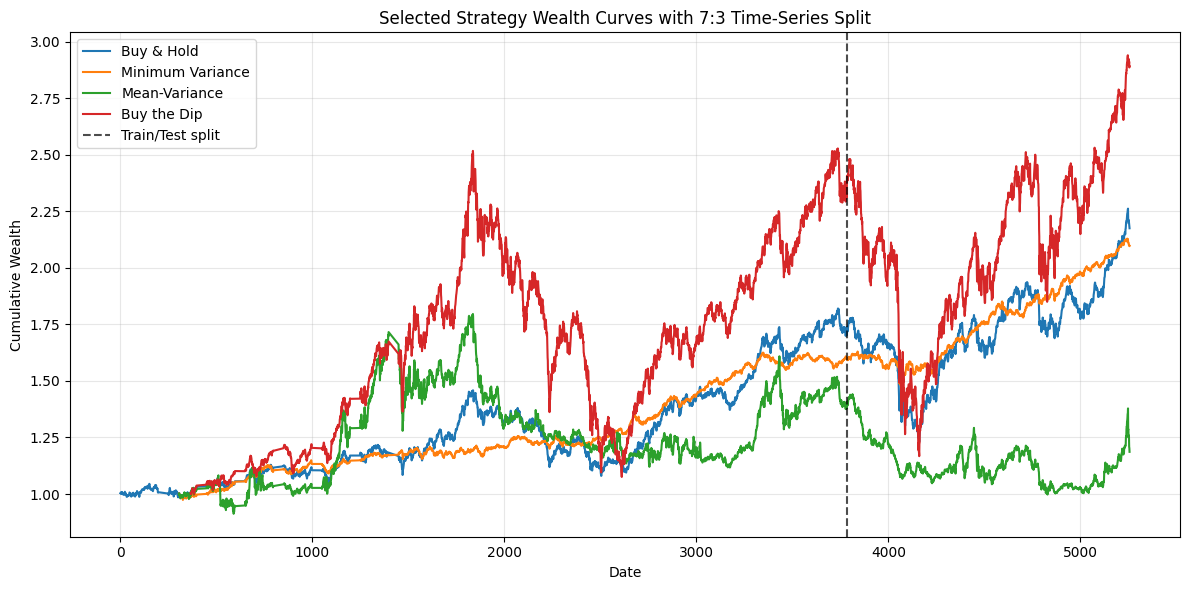

In [26]:
# IS/OOS strategy comparison with time-series 7:3 split
annualization = globals().get("annualization", 252)
rolling_sharpe_window = globals().get("rolling_sharpe_window", 63)
holding_period_map = {
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

split_idx = int(len(simple_ret) * 0.7)
split_date = simple_ret.index[split_idx - 1]

def pick_best_result_by_sharpe(result_dict):
    best_key = None
    best_res = None
    best_score = -np.inf

    for key, res in result_dict.items():
        sharpe = res.get("metrics", {}).get("sharpe_ratio", np.nan)
        score = -np.inf if pd.isna(sharpe) else float(sharpe)
        if score > best_score:
            best_score = score
            best_key = key
            best_res = res

    return best_key, best_res

def compute_turnover_from_weights(weights_df, simple_returns):
    if weights_df is None or weights_df.empty:
        return pd.Series(dtype=float, name="turnover")

    weights = weights_df.copy().sort_index()
    weights = weights.reindex(columns=simple_returns.columns).fillna(0.0)
    turnovers = []

    for i, date in enumerate(weights.index):
        current_w = weights.iloc[i].fillna(0.0)
        if i == 0:
            turnovers.append(0.0)
            continue

        prev_date = weights.index[i - 1]
        prev_w = weights.iloc[i - 1].fillna(0.0)
        prev_ret = simple_returns.loc[prev_date].reindex(weights.columns).fillna(0.0)
        position_values = prev_w * (1 + prev_ret)
        denom = position_values.sum()
        w_pre = prev_w if np.isclose(denom, 0) else position_values / denom
        turnover = 0.5 * np.abs(current_w - w_pre).sum()
        turnovers.append(float(turnover))

    return pd.Series(turnovers, index=weights.index, name="turnover")

def backtest_buy_and_hold_periodic(simple_returns, holding_period, annualization=252, rolling_window=63):
    simple_returns = simple_returns.dropna(how="any").copy()
    assets = simple_returns.columns.tolist()
    n_assets = len(assets)
    target_w = pd.Series(np.repeat(1 / n_assets, n_assets), index=assets, dtype=float)

    current_w = target_w.copy()
    portfolio_returns = []
    weights_history = []
    turnover_history = []

    for t, date in enumerate(simple_returns.index):
        if t == 0:
            w_trade = target_w.copy()
            turnover = 0.0
        elif t % holding_period == 0:
            w_trade = target_w.copy()
            turnover = 0.5 * np.abs(w_trade - current_w).sum()
        else:
            w_trade = current_w.copy()
            turnover = 0.0

        day_ret = simple_returns.loc[date].fillna(0.0)
        realized_ret = float(np.dot(w_trade.values, day_ret.values))

        portfolio_returns.append((date, realized_ret))
        weights_history.append(pd.Series(w_trade, name=date))
        turnover_history.append((date, float(turnover)))

        position_values = w_trade * (1 + day_ret)
        denom = position_values.sum()
        current_w = w_trade if np.isclose(denom, 0) else position_values / denom

    port_ret = pd.Series(
        [x[1] for x in portfolio_returns],
        index=[x[0] for x in portfolio_returns],
        name=f"buy_and_hold_{holding_period}"
    )
    weights_df = pd.DataFrame(weights_history)
    turnover_series = pd.Series(
        [x[1] for x in turnover_history],
        index=[x[0] for x in turnover_history],
        name="turnover"
    )
    metrics, wealth, drawdown = compute_metrics(
        port_ret,
        annualization=annualization,
        turnover_series=turnover_series,
        rolling_window=rolling_window,
    )

    return {
        "portfolio_returns": port_ret,
        "weights": weights_df,
        "turnover": turnover_series,
        "wealth": wealth,
        "drawdown": drawdown,
        "metrics": metrics,
        "holding_period": holding_period,
    }

def evaluate_result_is_oos(res, split_date, simple_returns, annualization=252, rolling_window=63):
    port_ret = res["portfolio_returns"].dropna().copy()

    if "turnover" in res and isinstance(res["turnover"], pd.Series) and not res["turnover"].empty:
        turnover_series = res["turnover"].reindex(port_ret.index).fillna(0.0)
    elif "weights" in res:
        turnover_series = compute_turnover_from_weights(
            res["weights"].reindex(port_ret.index),
            simple_returns,
        ).reindex(port_ret.index).fillna(0.0)
    else:
        turnover_series = pd.Series(0.0, index=port_ret.index, name="turnover")

    is_mask = port_ret.index <= split_date
    oos_mask = port_ret.index > split_date

    is_metrics, is_wealth, is_drawdown = compute_metrics(
        port_ret.loc[is_mask],
        annualization=annualization,
        turnover_series=turnover_series.loc[is_mask],
        rolling_window=rolling_window,
    )
    oos_metrics, oos_wealth, oos_drawdown = compute_metrics(
        port_ret.loc[oos_mask],
        annualization=annualization,
        turnover_series=turnover_series.loc[oos_mask],
        rolling_window=rolling_window,
    )

    return {
        "IS": is_metrics,
        "OOS": oos_metrics,
        "wealth": res.get("wealth"),
        "drawdown": res.get("drawdown"),
        "turnover": turnover_series,
        "portfolio_returns": port_ret,
        "weights": res.get("weights"),
    }

def build_metric_row(metrics):
    return {
        "Sharpe": metrics.get("sharpe_ratio", np.nan),
        "Mean Return": metrics.get("mean_return", np.nan),
        "Max Drawdown": metrics.get("max_drawdown", np.nan),
        "Annual Turnover": metrics.get("annual_turnover", np.nan),
        "Max Recovery Time": metrics.get("max_recovery_time_days", np.nan),
        "Rolling Sharpe stability": metrics.get("rolling_sharpe_stability", np.nan),
        "t-statistic": metrics.get("t_statistic", np.nan),
    }

def select_best_by_is(candidate_results, split_date, simple_returns, annualization=252, rolling_window=63):
    evaluations = {}
    ranking_rows = []

    for key, res in candidate_results.items():
        eval_res = evaluate_result_is_oos(
            res,
            split_date=split_date,
            simple_returns=simple_returns,
            annualization=annualization,
            rolling_window=rolling_window,
        )
        evaluations[key] = eval_res

        row = {"model": key}
        row.update(build_metric_row(eval_res["IS"]))
        row["Train Days"] = eval_res["IS"].get("n_days", 0)
        ranking_rows.append(row)

    ranking_df = pd.DataFrame(ranking_rows)
    ranking_df["_sort_sharpe"] = ranking_df["Sharpe"].fillna(-np.inf)
    ranking_df["_sort_mean_return"] = ranking_df["Mean Return"].fillna(-np.inf)
    ranking_df = (
        ranking_df
        .sort_values(["_sort_sharpe", "_sort_mean_return"], ascending=[False, False])
        .drop(columns=["_sort_sharpe", "_sort_mean_return"])
        .reset_index(drop=True)
    )
    best_key = ranking_df.loc[0, "model"]

    return best_key, candidate_results[best_key], evaluations[best_key], ranking_df, evaluations

def build_is_oos_metric_table(is_metrics, oos_metrics):
    metric_order = [
        "Sharpe",
        "Mean Return",
        "Max Drawdown",
        "Annual Turnover",
        "Max Recovery Time",
        "Rolling Sharpe stability",
        "t-statistic",
    ]

    mapping = {
        "Sharpe": (is_metrics.get("sharpe_ratio", np.nan), oos_metrics.get("sharpe_ratio", np.nan), lambda x: f"{x:.3f}"),
        "Mean Return": (is_metrics.get("mean_return", np.nan), oos_metrics.get("mean_return", np.nan), lambda x: f"{x:.2%}"),
        "Max Drawdown": (is_metrics.get("max_drawdown", np.nan), oos_metrics.get("max_drawdown", np.nan), lambda x: f"{x:.2%}"),
        "Annual Turnover": (is_metrics.get("annual_turnover", np.nan), oos_metrics.get("annual_turnover", np.nan), lambda x: f"{x:.1%}"),
        "Max Recovery Time": (is_metrics.get("max_recovery_time_days", np.nan), oos_metrics.get("max_recovery_time_days", np.nan), lambda x: f"{int(round(x))} days"),
        "Rolling Sharpe stability": (is_metrics.get("rolling_sharpe_stability", np.nan), oos_metrics.get("rolling_sharpe_stability", np.nan), lambda x: f"{x:.3f}"),
        "t-statistic": (is_metrics.get("t_statistic", np.nan), oos_metrics.get("t_statistic", np.nan), lambda x: f"{x:.2f}"),
    }

    rows = []
    for metric in metric_order:
        is_value, oos_value, formatter = mapping[metric]
        rows.append([
            "NaN" if pd.isna(is_value) else formatter(is_value),
            "NaN" if pd.isna(oos_value) else formatter(oos_value),
        ])

    return pd.DataFrame(rows, index=metric_order, columns=["IS", "OOS"])

def prepare_train_metric_table(strategy_name, ranking_df):
    table = ranking_df.copy()

    if strategy_name == "Buy & Hold":
        table = table.rename(columns={"model": "Holding Period"})
    elif strategy_name == "Minimum Variance Portfolio":
        table = table.rename(columns={"model": "Window"})
    elif strategy_name == "Mean-Variance Portfolio":
        param_df = table["model"].apply(
            lambda x: pd.Series({
                "Window": x[0] if isinstance(x, tuple) else x,
                "Risk Aversion": x[1] if isinstance(x, tuple) and len(x) > 1 else np.nan,
            })
        )
        table = pd.concat([param_df, table.drop(columns="model")], axis=1)
    elif strategy_name == "Buy the Dip":
        param_df = table["model"].apply(
            lambda x: pd.Series({
                "Window": x[0],
                "Quantile": x[1],
                "Alpha": x[2],
                "Beta": x[3],
            })
        )
        table = pd.concat([param_df, table.drop(columns="model")], axis=1)

    return table

metric_formatters = {
    "Sharpe": "{:.3f}",
    "Mean Return": "{:.2%}",
    "Max Drawdown": "{:.2%}",
    "Annual Turnover": "{:.1%}",
    "Max Recovery Time": "{:.0f} days",
    "Rolling Sharpe stability": "{:.3f}",
    "t-statistic": "{:.2f}",
}
train_table_formatters = {
    **metric_formatters,
    "Train Days": "{:.0f}",
    "Quantile": "{:.0%}",
    "Alpha": "{:.2f}",
    "Beta": "{:.2f}",
    "Risk Aversion": "{:.2f}",
}

bh_candidate_results = {
    label: backtest_buy_and_hold_periodic(
        simple_ret,
        holding_period=holding_period,
        annualization=annualization,
        rolling_window=rolling_sharpe_window,
    )
    for label, holding_period in holding_period_map.items()
}

best_bh_key, best_bh_res, best_bh_eval, bh_ranking_df, _ = select_best_by_is(
    bh_candidate_results,
    split_date=split_date,
    simple_returns=simple_ret,
    annualization=annualization,
    rolling_window=rolling_sharpe_window,
)

best_min_key, best_min_res, best_min_eval, min_ranking_df, _ = select_best_by_is(
    results,
    split_date=split_date,
    simple_returns=simple_ret,
    annualization=annualization,
    rolling_window=rolling_sharpe_window,
)

best_mv_key, best_mv_res, best_mv_eval, mv_ranking_df, _ = select_best_by_is(
    mv_results,
    split_date=split_date,
    simple_returns=simple_ret,
    annualization=annualization,
    rolling_window=rolling_sharpe_window,
)

best_btd_key, best_btd_res, best_btd_eval, btd_ranking_df, _ = select_best_by_is(
    btd_grid_results,
    split_date=split_date,
    simple_returns=simple_ret,
    annualization=annualization,
    rolling_window=rolling_sharpe_window,
)

selection_summary_df = pd.DataFrame([
    {
        "Strategy": "Buy & Hold",
        "Selected Model": f"Holding period = {best_bh_key}",
        "Train Sharpe": best_bh_eval["IS"].get("sharpe_ratio", np.nan),
        "Test Sharpe": best_bh_eval["OOS"].get("sharpe_ratio", np.nan),
    },
    {
        "Strategy": "Minimum Variance Portfolio",
        "Selected Model": f"Window = {best_min_key}",
        "Train Sharpe": best_min_eval["IS"].get("sharpe_ratio", np.nan),
        "Test Sharpe": best_min_eval["OOS"].get("sharpe_ratio", np.nan),
    },
    {
        "Strategy": "Mean-Variance Portfolio",
        "Selected Model": f"Window = {best_mv_key[0]}, risk_aversion = {best_mv_key[1]}",
        "Train Sharpe": best_mv_eval["IS"].get("sharpe_ratio", np.nan),
        "Test Sharpe": best_mv_eval["OOS"].get("sharpe_ratio", np.nan),
    },
    {
        "Strategy": "Buy the Dip",
        "Selected Model": f"window={best_btd_key[0]}, q={best_btd_key[1]:.0%}, alpha={best_btd_key[2]}, beta={best_btd_key[3]}",
        "Train Sharpe": best_btd_eval["IS"].get("sharpe_ratio", np.nan),
        "Test Sharpe": best_btd_eval["OOS"].get("sharpe_ratio", np.nan),
    },
])

train_metric_tables = {
    "Buy & Hold": prepare_train_metric_table("Buy & Hold", bh_ranking_df),
    "Minimum Variance Portfolio": prepare_train_metric_table("Minimum Variance Portfolio", min_ranking_df),
    "Mean-Variance Portfolio": prepare_train_metric_table("Mean-Variance Portfolio", mv_ranking_df),
    "Buy the Dip": prepare_train_metric_table("Buy the Dip", btd_ranking_df),
}

selected_test_summary_df = pd.DataFrame([
    {
        "Strategy": "Buy & Hold",
        "Selected Model": f"Holding period = {best_bh_key}",
        **build_metric_row(best_bh_eval["OOS"]),
    },
    {
        "Strategy": "Minimum Variance Portfolio",
        "Selected Model": f"Window = {best_min_key}",
        **build_metric_row(best_min_eval["OOS"]),
    },
    {
        "Strategy": "Mean-Variance Portfolio",
        "Selected Model": f"Window = {best_mv_key[0]}, risk_aversion = {best_mv_key[1]}",
        **build_metric_row(best_mv_eval["OOS"]),
    },
    {
        "Strategy": "Buy the Dip",
        "Selected Model": f"window={best_btd_key[0]}, q={best_btd_key[1]:.0%}, alpha={best_btd_key[2]}, beta={best_btd_key[3]}",
        **build_metric_row(best_btd_eval["OOS"]),
    },
])

display(selection_summary_df.style.format({"Train Sharpe": "{:.3f}", "Test Sharpe": "{:.3f}"}))
print("Split date:", split_date)
print("Train observations:", split_idx, "| Test observations:", len(simple_ret) - split_idx)

for strategy_name in [
    "Buy & Hold",
    "Minimum Variance Portfolio",
    "Mean-Variance Portfolio",
    "Buy the Dip",
]:
    print(f"\n{strategy_name} | Train performance for all parameter combinations")
    display(train_metric_tables[strategy_name].style.format(train_table_formatters))

print("\nSelected best-train-Sharpe models | Test performance")
display(selected_test_summary_df.style.format(metric_formatters))

selected_full_results = {
    "Buy & Hold": best_bh_res,
    "Minimum Variance": best_min_res,
    "Mean-Variance": best_mv_res,
    "Buy the Dip": best_btd_res,
}

plt.figure(figsize=(12, 6))
for strategy_name, res in selected_full_results.items():
    plt.plot(res["wealth"].index, res["wealth"], label=strategy_name)
plt.axvline(split_date, color="black", linestyle="--", alpha=0.7, label="Train/Test split")
plt.title("Selected Strategy Wealth Curves with 7:3 Time-Series Split")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Buy the Dip 전략은 일정 기준 하락한 종목에 대해서 추가로 매수하는 전략이다. 이는 가격이 평균으로 돌아온다는 가정하에 일정 기준 하락한 종목을 구매하는 전략이다.
여기서 우리는 일정 기준 하락 폭을 결정해야하고, 하락의 폭을 계산할 때 어느 구간을 기준으로 하락을 계산해야하는지의 window를 결정할 필요가 있다.
Window는 6개월, 1년, 2년 그리고 3년을 기준으로 하고, 이 기간내에서의 Drawdown을 구해, 이를 기준으로 매수의 기준을 설정하고자 한다.
그러나 위 분석에서 보듯이 각 종목마다 하락 폭의 분포가 다르기에 공통된 일정 수치를 적용하기보다 각 종목마다 기준을 다르게 잡는것이 합리적이라 판단했다. 따라서 각 종목의 Qauntile을 기준으로 70%, 90% 이상 하락했을때를 매수 신호로 설정했다.
그리고 하락했을때 얼마나 매수할 것인가? 그리고 어떤 종목을 얼만큼 팔아서 매수할 것인가? 에 대해서 Rule을 세웠다. 또한, 위 Rule을 따라 전략을 진행하였을 때, 특정 종목에 몰빵이 되어 Portfolio가 경직되는 경우를 지양하기 위해서 매수여력*beta를 하여 한번에 매수하는 비중을 제한하였다.
마찬가지로 분석의 단순화를 위해서 alpha와 beta는 각각 [1, 0.5], [0.4, 0.6]에 대해서만 분석하였다. 또한 마찬가지로 위 portfolio는 매일 rebalancing을 진행한다.

The Buy the Dip strategy involves purchasing additional shares of an asset after its price has declined by a certain threshold. This strategy is based on the assumption of mean reversion, where prices are expected to return to their average levels after a significant drop.

In implementing this strategy, we must determine the specific threshold for the price decline and the look-back window used to calculate this drop. We established windows of 6 months, 1 year, 2 years, and 3 years, calculating the Drawdown within these periods to set our entry signals.

However, as shown in the previous analysis, the distribution of price declines varies significantly across different assets. Therefore, rather than applying a universal fixed value, we concluded that it is more rational to set asset-specific thresholds. Consequently, we defined buy signals based on quantiles, triggering a purchase when a drawdown reaches the 70th or 90th percentile of its historical distribution.

Furthermore, we established specific rules regarding the execution: how much to buy and which assets to liquidate to fund these purchases. To prevent the portfolio from becoming overly concentrated in a single asset—which would reduce portfolio flexibility—we limited the size of each trade by multiplying the available "buying power" by a beta factor.

For the sake of simplifying the analysis, we tested specific values for alpha and beta: [1, 0.5] and [0.4, 0.6], respectively. Additionally, the portfolio undergoes daily rebalancing.